## Evaluate

In [7]:
import re, json
import numpy as np
import torch
import nltk
from torchmetrics.text.rouge import ROUGEScore
from bert_score import score as bert_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="huggingface_hub.file_download"
)


# init
rougeScore = ROUGEScore()
_smoothie = SmoothingFunction().method4

def get_bleu(recover, reference):
    return sentence_bleu([reference.split()], recover.split(), smoothing_function=_smoothie)

def selectBest(sentences):
    selfBleu = [[] for _ in range(len(sentences))]
    for i, s1 in enumerate(sentences):
        for j, s2 in enumerate(sentences):
            selfBleu[i].append(get_bleu(s1, s2))
    for i in range(len(sentences)):
        selfBleu[i][i] = 0
    idx = np.argmax(np.sum(selfBleu, -1))
    return sentences[idx]

def diversityOfSet(sentences):
    selfBleu = []
    for i, s1 in enumerate(sentences):
        for j in range(i+1, len(sentences)):
            selfBleu.append(get_bleu(s1, sentences[j]))
    if len(selfBleu) == 0:
        selfBleu.append(0)
    div4 = distinct_n_gram_inter_sent(sentences, 4)
    return np.mean(selfBleu), div4

def distinct_n_gram(hypn, n):
    dist_list = []
    for hyp in hypn:
        hyp_ngrams = list(nltk.ngrams(hyp.split(), n))
        total_ngrams = len(hyp_ngrams)
        unique_ngrams = len(set(hyp_ngrams))
        if total_ngrams == 0:
            return 0
        dist_list.append(unique_ngrams / total_ngrams)
    return np.mean(dist_list)

def distinct_n_gram_inter_sent(hypn, n):
    hyp_ngrams = []
    for hyp in hypn:
        hyp_ngrams += list(nltk.ngrams(hyp.split(), n))
    total_ngrams = len(hyp_ngrams)
    unique_ngrams = len(set(hyp_ngrams))
    if total_ngrams == 0:
        return 0
    return unique_ngrams / total_ngrams

import re

# def parse_samples_txt(path):
#     """Parse [Sample N-runK] blocks with Source/Output/Target lines."""
#     with open(path, "r", encoding="utf-8") as f:
#         text = f.read()

#     # Normalize newlines
#     text = text.replace("\r\n", "\n").replace("\r", "\n")

#     # Split on separator lines (---) → each block
#     blocks = re.split(r"-{5,}", text)
#     rows = []

#     for b in blocks:
#         if "Source" not in b:
#             continue

#         def grab(label):
#             m = re.search(rf"{label}\s*:\s*(.*)", b)
#             return m.group(1).strip() if m else None

#         src = grab("Source")
#         out = grab("Output")
#         tgt = grab("Target")

#         if src and out and tgt:
#             rows.append({
#                 "source": src,
#                 "recover": out,
#                 "reference": tgt,
#             })

#     return rows

def parse_samples_txt(path):
    """
    Parse blocks like:
      [Sample N]           or   [Sample N-runK]
      Source : ...
      Output : ...
      Target : ...
      (optional) '#### answer' line
      (optional) '---------------' separator between samples
    """
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().replace("\r\n", "\n").replace("\r", "\n")

    pattern = re.compile(
        r"""
        \[\s*Sample\s+\d+(?:-[^\]]+)?\]\s*   # [Sample 12] or [Sample 12-run3]
        Source\s*:\s*(.*?)\n                 # Source : <line (can be long)>
        Output\s*:\s*(.*?)\n                 # Output : <line (can be long)>
        Target\s*:\s*(.*?)                   # Target : <multi-line until stop>
        (?:\n\#{4}[^\n]*\n?)?                # optional '#### ...' line (#### escaped)
        (?=                                  # STOP before (lookahead):
            \n-+\n                           #   dashed separator
          | \n\[\s*Sample                    #   next [Sample ...]
          | \Z                               #   or end of file
        )
        """,
        re.DOTALL | re.VERBOSE,
    )

    rows = []
    for m in pattern.finditer(text):
        rows.append({
            "source": m.group(1).strip(),
            "recover": m.group(2).strip(),
            "reference": m.group(3).strip(),
        })
    return rows



from collections import defaultdict

def evaluate_samples_txt(path, compute_diversity=True, Bert_score=True):
    """
    Evaluate metrics from a samples.txt file.
    - compute_diversity=True → compute self-BLEU/div-4 per source (average over sources)
    - mbr=True → selectBest decoding per source (if multiple outputs exist)
    """
    rows = parse_samples_txt(path)
    if not rows:
        raise ValueError("No samples parsed.")

    bleu, rougel, avg_len, dist1 = [], [], [], []
    recovers, references = [], []

    # group outputs by source text
    by_source = defaultdict(list)
    by_reference = defaultdict(list)

    for obj in rows:
        src = obj["source"].strip()
        ref = obj["reference"].strip()
        rec = obj["recover"].strip()

        # clean tokens
        for tok in ["[SEP]", "[CLS]", "[PAD]"]:
            src = src.replace(tok, "")
            ref = ref.replace(tok, "")
            rec = rec.replace(tok, "")
        
        if len(rec.strip()) == 0 or len(ref.strip()) == 0:
            print("\n[EMPTY CANDIDATE/REFERENCE]")
            print(" Path:", path)
            print(" Source:", repr(src))
            print(" Output:", repr(rec))
            print(" Target:", repr(ref))
            print("-" * 60)

        recovers.append(rec)
        references.append(ref)

        by_source[src].append(rec)
        by_reference[src].append(ref)

        avg_len.append(len(rec.split()))
        bleu.append(get_bleu(rec, ref))
        rougel.append(rougeScore(rec, ref)["rougeL_fmeasure"].item())
        dist1.append(distinct_n_gram([rec], 1))

    # BERTScore
    if Bert_score:
        P, R, F1 = bert_score(recovers, references,
                          model_type="microsoft/deberta-xlarge-mnli",
                          lang="en", verbose=False)
        results = {
            "avg_bleu": float(np.mean(bleu)),
            "avg_rougeL": float(np.mean(rougel)),
            "avg_bertscore_f1": float(torch.mean(F1)),
            "avg_dist1": float(np.mean(dist1)),
            "avg_len": float(np.mean(avg_len)),
        }
    else:   
        results = {
            "avg_bleu": float(np.mean(bleu)),
            "avg_rougeL": float(np.mean(rougel)),
            "avg_dist1": float(np.mean(dist1)),
            "avg_len": float(np.mean(avg_len)),
        }
    # Diversity: compute per source, then average
    if compute_diversity:
        selfBleus, div4s = [], []
        # print("Number of unique sources:", len(by_source))
        # for src, outs in list(by_source.items())[:3]:   # show only first 3 to avoid spam
        #     print("="*40)
        #     print("SOURCE:", src)
        #     print("Num outputs collected:", len(outs))
        #     for o in outs:
        #         print("  -", o)

        for outs in by_source.values():
            if not outs:
                continue
            sb, d4 = diversityOfSet(outs)  
            selfBleus.append(sb)
            div4s.append(d4)
        results["avg_selfBleu"] = float(np.mean(selfBleus))
        results["avg_div4"] = float(np.mean(div4s))

    return results

## Greetings Dataset

### Without Gradient Clipping

In [9]:
# Define models and their file paths
models = {
    "GPT2": "models/final models/greetings/samples_gpt2_scratch_greet_2000_0827_0151.txt",
    # "DiffuSeq": "models/final models/greetings/final models no clip/samples_multiple_Bert_greet_2000_noclip_0901_2134.txt",
    "Diffuseq" : "models/final models/greetings/final models no clip/samples_multiple_Bert_greet_2000_noclip.txt",
    "SwitchDiffuSeq-2e": "models/final models/greetings/final models no clip/samples_multiple_Switch_2e_greet_2000_noclip_0901_1930.txt",
    "SwitchDiffuSeq-4e": "models/final models/greetings/final models no clip/samples_multiple_Switch_4e_greet_2000_noclip_0901_2053.txt",
    "SwitchDiffuSeq-8e": "models/final models/greetings/final models no clip/samples_multiple_Switch_8e_greet_2000_noclip_0901_2119.txt",
}

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path, Bert_score=True)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")


\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
GPT2 & 0.104 & 0.317 & 0.654 & 0.841 & 0.579 & 0.488 & 16.3 \\
Diffuseq & 0.029 & 0.210 & 0.498 & 0.919 & 0.048 & 0.991 & 8.3 \\
SwitchDiffuSeq-2e & 0.029 & 0.204 & 0.495 & 0.915 & 0.042 & 0.995 & 8.9 \\
SwitchDiffuSeq-4e & 0.028 & 0.222 & 0.532 & 0.931 & 0.069 & 0.977 & 8.6 \\
SwitchDiffuSeq-8e & 0.025 & 0.204 & 0.513 & 0.921 & 0.078 & 0.970 & 8.4 \\
\bottomrule
\end{tabular}}
\end{table*}


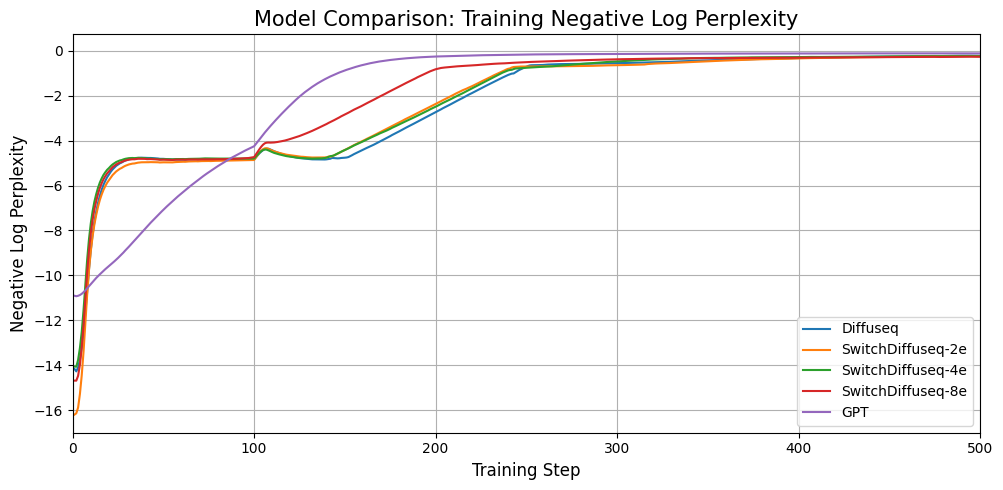

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

model_files = {
    "Diffuseq" : "models/final models/greetings/final models no clip/Bert_greet_2000_noclip_0901_2152/ppl_progress_multiple_Bert_greet_2000_noclip_0901_2152.csv",
    "SwitchDiffuseq-2e": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_2e_greet_2000_noclip_0901_1843.csv",
    # "Switch-2e" : "diffusion-text-generation/models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/ppl_progress_Switch_2e_greet_2000_noclip_cap=1_0902_1335.csv",
    "SwitchDiffuseq-4e": "models/final models/greetings/final models no clip/multiple_Switch_4e_greet_2000_no_clip_cap=1.75/ppl_progress_multiple_Switch_4e_greet_2000_no_clip_0904_1623.csv",
    "SwitchDiffuseq-8e" : "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_8e_greet_2000_noclip_0901_1912.csv",
    "GPT" : "models/final models/greetings/gpt2_scratch_greet_2000_0825_1030/ppl_progress_gpt2_scratch_greet_2000_0825_1030.csv",
}

plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    row = df[df["step"] == 100]
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step", fontsize=12)
    
plt.ylabel("Negative Log Perplexity", fontsize=12)
plt.title("Model Comparison: Training Negative Log Perplexity", fontsize=15)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 500)
# plt.ylim(-10, 1)
plt.savefig("greet_nlp_noclip.png", dpi=300, bbox_inches="tight")
plt.show()


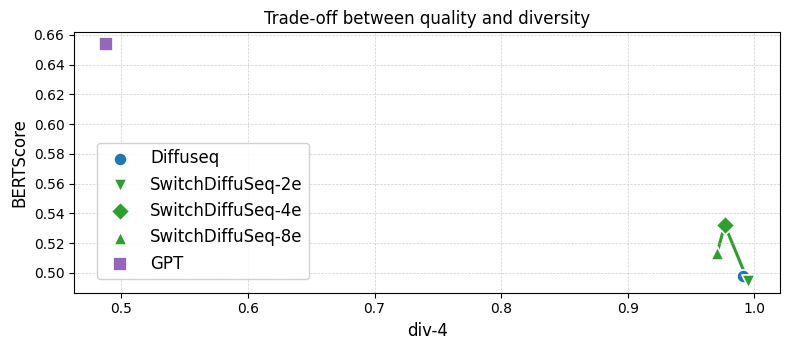

In [4]:

import os
import pandas as pd
import matplotlib.pyplot as plt

RUNS = {
    "Diffuseq": "models/final models/greetings/final models no clip/samples_multiple_Bert_greet_2000_noclip.txt",
    "SwitchDiffuSeq-2e": "models/final models/greetings/final models no clip/samples_multiple_Switch_2e_greet_2000_noclip_0901_1930.txt",
    "SwitchDiffuSeq-4e": "models/final models/greetings/final models no clip/samples_multiple_Switch_4e_greet_2000_noclip_0901_2053.txt",
    "SwitchDiffuSeq-8e" : "models/final models/greetings/final models no clip/samples_multiple_Switch_8e_greet_2000_noclip_0901_2119.txt",
    "GPT" : "models/final models/greetings/samples_gpt2_scratch_greet_2000_0827_0151.txt",
}


records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "score":  s["avg_bertscore_f1"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "Diffuseq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT": "s"                   # sqaure
}

colors = {
    "Diffuseq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT": "tab:purple"
}

# scatter points
# connect Switch models (draw UNDER markers)
switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["score"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["score"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   # re-add label for legend
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           # put it inside bottom-left
    bbox_to_anchor=(0.02, 0.02), # small offset from corner
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BERTScore", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("greet_QD_noclip.png", dpi=300, bbox_inches="tight")
plt.show()

### With Gradient Clipping

In [5]:
# Define models and their file paths
models = {
    "GPT" : "models/final models/greetings/samples_gpt2_scratch_greet_2000_0827_0151.txt",
    "Diffuseq": "models/final models/greetings/clip/samples_multiple__Bert_clip_greet_2000_0831_1153.txt",
    "SwitchDiffuSeq-2e": "models/final models/greetings/clip/samples_multiple__Switch_2e_clip_greet_2000_0831_1216.txt",
    "SwitchDiffuSeq-4e": "models/final models/greetings/clip/samples_multiple__Switch_4e_clip_greet_2000_0831_1234.txt",
    "SwitchDiffuSeq-8e" : "models/final models/greetings/clip/samples_multiple_Switch_8e_clip_greet_2000_0831_1301.txt",
}

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path, Bert_score=True)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")


\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
GPT & 0.104 & 0.317 & 0.654 & 0.841 & 0.579 & 0.488 & 16.3 \\
Diffuseq & 0.055 & 0.257 & 0.597 & 0.974 & 0.133 & 0.923 & 8.4 \\
SwitchDiffuSeq-2e & 0.055 & 0.246 & 0.609 & 0.967 & 0.160 & 0.896 & 8.6 \\
SwitchDiffuSeq-4e & 0.064 & 0.265 & 0.601 & 0.963 & 0.154 & 0.895 & 8.8 \\
SwitchDiffuSeq-8e & 0.071 & 0.279 & 0.590 & 0.954 & 0.148 & 0.912 & 8.4 \\
\bottomrule
\end{tabular}}
\end{table*}


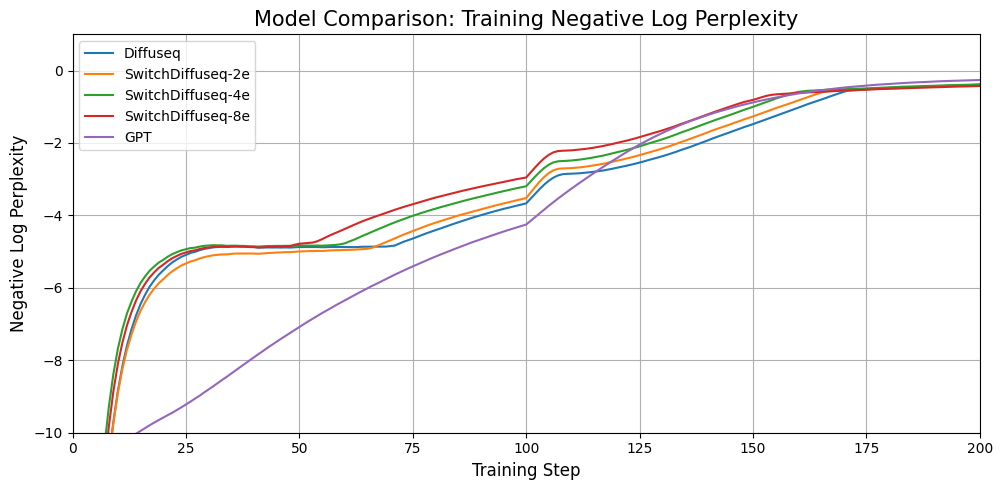

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

model_files = {
    "Diffuseq": "models/final models/greetings/clip/multiple_Bert_greet_2000_with_clip/ppl_progress_multiple_Bert_greet_2000_0831_0016.csv",
    "SwitchDiffuseq-2e": "models/final models/greetings/clip/multiple_Switch_2e_clip_greet_2000_0831_0115/ppl_progress_multiple_Switch_2e_clip_greet_2000_0831_0115.csv",
    "SwitchDiffuseq-4e": "models/final models/greetings/clip/multiple_Switch_4e_clip_greet_2000_0831_1058/ppl_progress_multiple_Switch_4e_clip_greet_2000_0831_1058.csv",
    "SwitchDiffuseq-8e" : "models/final models/greetings/clip/multiple_Switch_8e_clip_greet_2000_0831_1142/ppl_progress_multiple_Switch_8e_clip_greet_2000_0831_1142.csv",
    "GPT" : "models/final models/greetings/gpt2_scratch_greet_2000_0825_1030/ppl_progress_gpt2_scratch_greet_2000_0825_1030.csv",
}

plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    row = df[df["step"] == 100]
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step", fontsize=12)
    
plt.ylabel("Negative Log Perplexity", fontsize=12)
plt.title("Model Comparison: Training Negative Log Perplexity", fontsize=15)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 200)
plt.ylim(-10, 1)
plt.savefig("greeting_nlp.png", dpi=300, bbox_inches="tight")
plt.show()


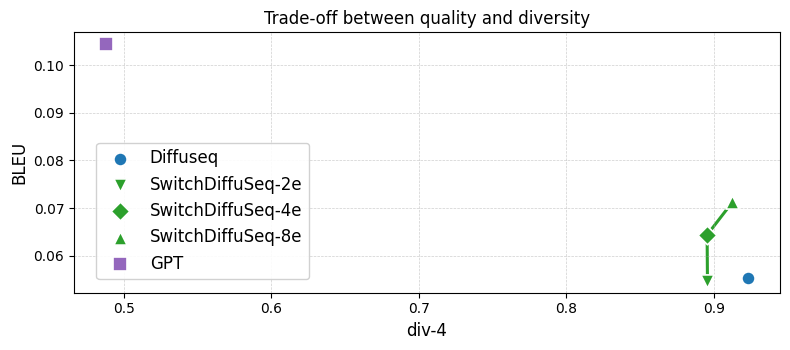

In [7]:

import os
import pandas as pd
import matplotlib.pyplot as plt

RUNS = {
    "Diffuseq": "models/final models/greetings/clip/samples_multiple__Bert_clip_greet_2000_0831_1153.txt",
    "SwitchDiffuSeq-2e": "models/final models/greetings/clip/samples_multiple__Switch_2e_clip_greet_2000_0831_1216.txt",
    "SwitchDiffuSeq-4e": "models/final models/greetings/clip/samples_multiple__Switch_4e_clip_greet_2000_0831_1234.txt",
    "SwitchDiffuSeq-8e" : "models/final models/greetings/clip/samples_multiple_Switch_8e_clip_greet_2000_0831_1301.txt",
    "GPT" : "models/final models/greetings/samples_gpt2_scratch_greet_2000_0827_0151.txt",
}


records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "bleu":  s["avg_bleu"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "Diffuseq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT": "s"                   # sqaure
}

colors = {
    "Diffuseq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT": "tab:purple"
}


switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["bleu"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["bleu"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           
    bbox_to_anchor=(0.02, 0.02), 
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BLEU", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("greet_QD.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
rows = parse_samples_txt("models/final models/greetings/final models no clip/samples_multiple_Bert_greet_2000_noclip.txt")
ref_lens = [len(obj["reference"].split()) for obj in rows]
print("Average reference length:", np.mean(ref_lens))

Average reference length: 11.0


## GSM8k

In [17]:
rows = parse_samples_txt("models/final models/math/final no clip/multiple_Bert_gsm8k_2000_noclip/samples_multiple_Bert_gsm8k_2000_noclip_0902_0156.txt")
ref_lens = [len(obj["reference"].split()) for obj in rows]
print("Average reference length:", np.mean(ref_lens))

Average reference length: 94.26666666666667


### Without Clipping

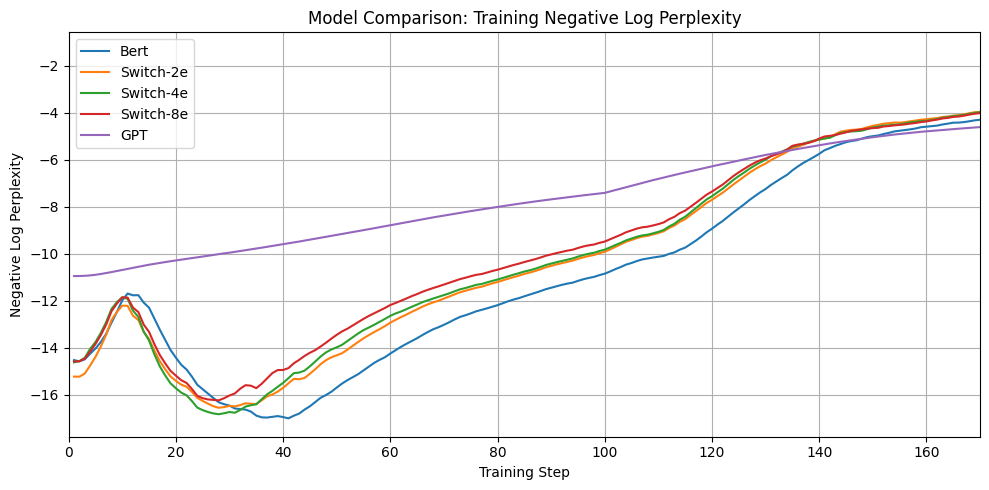

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_files = {
    "Bert": "models/final models/math/final no clip/multiple_Bert_gsm8k_2000_noclip/ppl_progress_multiple_Bert_gsm8k_2000_noclip_0902_0135.csv", 
    "Switch-2e": "models/final models/math/final no clip/multiple_Switch_2e_gsm8k_2000_noclip/ppl_progress_multiple_Switch_2e_gsm8k_2000_noclip_0902_0144.csv",
    "Switch-4e": "models/final models/math/final no clip/multiple_Switch_4e_gsm8k_2000_noclip/ppl_progress_multiple_Switch_4e_gsm8k_2000_noclip_0902_0157.csv",
    "Switch-8e": "models/final models/math/final no clip/multiple_Switch_8e_gsm8k_2000_noclip/ppl_progress_multiple_Switch_8e_gsm8k_2000_noclip_0902_0203.csv",
    "GPT" : "models/final models/math/gpt2_scratch_gsm8k_2000/ppl_progress_gpt2_scratch_gsm8k_2000_0825_1015.csv",
}

plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 170)
# plt.ylim(-16, -2)
plt.show()

In [8]:
# Define models and their file paths
models = {
    "GPT2": "models/final models/math/gpt2_scratch_gsm8k_2000/samples.txt",
    "DiffuSeq": "models/final models/math/final no clip/multiple_Bert_gsm8k_2000_noclip/samples_multiple_Bert_gsm8k_2000_noclip_0902_0156.txt",
    "SwitchDiffuSeq-2e": "models/final models/math/final no clip/multiple_Switch_2e_gsm8k_2000_noclip/samples_multiple_Switch_2e_gsm8k_2000_noclip_0902_0201.txt",
    "SwitchDiffuSeq-4e": "models/final models/math/final no clip/multiple_Switch_4e_gsm8k_2000_noclip/samples_multiple_Switch_4e_gsm8k_2000_noclip_0902_0219.txt",
    "SwitchDiffuSeq-8e": "models/final models/math/final no clip/multiple_Switch_8e_gsm8k_2000_noclip/samples_multiple_Switch_8e_gsm8k_2000_noclip_0902_0234.txt",
}

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")

\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
GPT2 & 0.022 & 0.202 & 0.581 & 0.567 & 0.000 & 0.816 & 29.9 \\
DiffuSeq & 0.014 & 0.129 & 0.451 & 0.535 & 0.000 & 1.000 & 46.4 \\
SwitchDiffuSeq-2e & 0.017 & 0.090 & 0.460 & 0.534 & 0.000 & 1.000 & 44.7 \\
SwitchDiffuSeq-4e & 0.023 & 0.078 & 0.461 & 0.513 & 0.000 & 1.000 & 54.5 \\
SwitchDiffuSeq-8e & 0.015 & 0.109 & 0.457 & 0.537 & 0.000 & 0.998 & 47.6 \\
\bottomrule
\end{tabular}}
\end{table*}


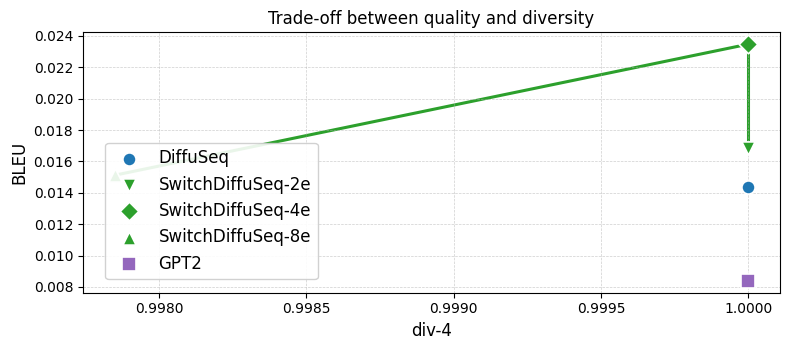

In [11]:

import os
import pandas as pd
import matplotlib.pyplot as plt

RUNS = {
    "DiffuSeq": "models/final models/math/final no clip/multiple_Bert_gsm8k_2000_noclip/samples_multiple_Bert_gsm8k_2000_noclip_0902_0156.txt",
    "SwitchDiffuSeq-2e": "models/final models/math/final no clip/multiple_Switch_2e_gsm8k_2000_noclip/samples_multiple_Switch_2e_gsm8k_2000_noclip_0902_0201.txt",
    "SwitchDiffuSeq-4e": "models/final models/math/final no clip/multiple_Switch_4e_gsm8k_2000_noclip/samples_multiple_Switch_4e_gsm8k_2000_noclip_0902_0219.txt",
    "SwitchDiffuSeq-8e": "models/final models/math/final no clip/multiple_Switch_8e_gsm8k_2000_noclip/samples_multiple_Switch_8e_gsm8k_2000_noclip_0902_0234.txt",
    "GPT2": "models/final models/math/gpt2_scratch_gsm8k_2000/samples.txt",
}


records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "bleu":  s["avg_bleu"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "DiffuSeq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT2": "s"                   # sqaure
}

colors = {
    "DiffuSeq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT2": "tab:purple"
}

# scatter points

switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["bleu"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["bleu"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           # put it inside bottom-left
    bbox_to_anchor=(0.02, 0.02), # small offset from corner
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BLEU", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("gsm8k_QD_noclip.png", dpi=300, bbox_inches="tight")
plt.show()

### With Clipping

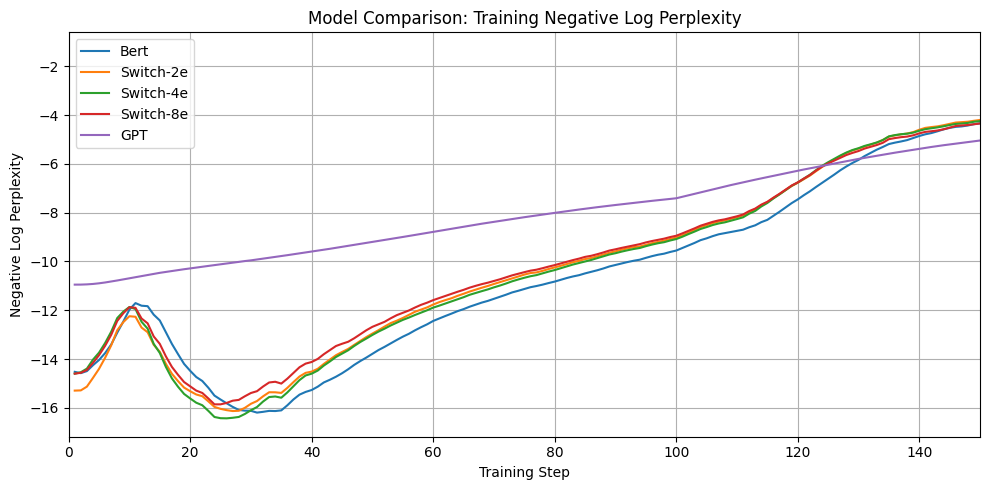

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_files = {
    "Bert": "models/final models/math/clip/multiple_bert_gsm8k_2000_clip/ppl_progress_multiple_bert_gsm8k_2000_0831_1349.csv", 
    "Switch-2e": "models/final models/math/clip/multiple_Switch_2e_gsm8k_clip/ppl_progress_multiple_Switch_2e_gsm8k_2000_0831_1406.csv",
    "Switch-4e": "models/final models/math/clip/multiple_Switch_4e_gsm8k_2000_clip/ppl_progress_multiple_Switch_4e_gsm8k_2000_0831_1415.csv",
    "Switch-8e": "models/final models/math/clip/multiple_Switch_8e_gsm8k_2000_0831_1531/ppl_progress_multiple_Switch_8e_gsm8k_2000_0831_1531.csv",
    "GPT" : "models/final models/math/gpt2_scratch_gsm8k_2000/ppl_progress_gpt2_scratch_gsm8k_2000_0825_1015.csv",
}

plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 150)
# plt.ylim(-16, -1)
plt.savefig("gsm8k_nlp.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# Define models and their file paths
models = {
    "GPT2": "models/final models/math/gpt2_scratch_gsm8k_2000/samples.txt",
    "DiffuSeq": "models/final models/math/clip/samples_multiple_Bert_gsm8k_2000_clip_0831_1550.txt",
    "SwitchDiffuSeq-2e": "models/final models/math/clip/samples_multiple_Switch_2e_gsm8k_2000_clip_0831_1601.txt",
    "SwitchDiffuSeq-4e": "models/final models/math/clip/samples_multiple_Switch_4e_gsm8k_2000_clip_0903_1729.txt",
    "SwitchDiffuSeq-8e": "models/final models/math/clip/samples_multiple_Switch_8e_gsm8k_2000_clip_0903_1741.txt",
}

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path, Bert_score=True)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")

\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
GPT2 & 0.022 & 0.202 & 0.581 & 0.567 & 0.000 & 0.816 & 29.9 \\
DiffuSeq & 0.023 & 0.125 & 0.463 & 0.507 & 0.000 & 1.000 & 56.5 \\
SwitchDiffuSeq-2e & 0.020 & 0.101 & 0.462 & 0.520 & 0.000 & 1.000 & 55.1 \\
SwitchDiffuSeq-4e & 0.019 & 0.089 & 0.458 & 0.523 & 0.040 & 0.999 & 45.8 \\
SwitchDiffuSeq-8e & 0.018 & 0.088 & 0.461 & 0.537 & 0.036 & 0.999 & 44.8 \\
\bottomrule
\end{tabular}}
\end{table*}


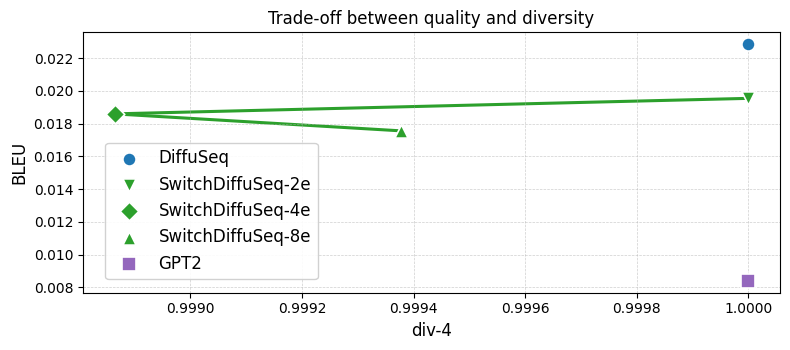

In [14]:

import os
import pandas as pd
import matplotlib.pyplot as plt

RUNS = {
    "DiffuSeq": "models/final models/math/clip/samples_multiple_Bert_gsm8k_2000_clip_0831_1550.txt",
    "SwitchDiffuSeq-2e": "models/final models/math/clip/samples_multiple_Switch_2e_gsm8k_2000_clip_0831_1601.txt",
    "SwitchDiffuSeq-4e": "models/final models/math/clip/samples_multiple_Switch_4e_gsm8k_2000_clip_0903_1729.txt",
    "SwitchDiffuSeq-8e": "models/final models/math/clip/samples_multiple_Switch_8e_gsm8k_2000_clip_0903_1741.txt",
    "GPT2": "models/final models/math/gpt2_scratch_gsm8k_2000/samples.txt",
}


records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "bleu":  s["avg_bleu"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "DiffuSeq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT2": "s"                   # sqaure
}

colors = {
    "DiffuSeq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT2": "tab:purple"
}

# scatter points

switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["bleu"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["bleu"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           
    bbox_to_anchor=(0.02, 0.02), 
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BLEU", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("gsm8k_QD.png", dpi=300, bbox_inches="tight")
plt.show()

## Paraphrase

In [26]:
rows = parse_samples_txt("models/final models/QQP/no clip/samples_multiple_Bert_QQP_2000_0830_1507.txt")
ref_lens = [len(obj["reference"].split()) for obj in rows]
print("Average reference length:", np.mean(ref_lens))

Average reference length: 11.75


### Without Gradient Clipping

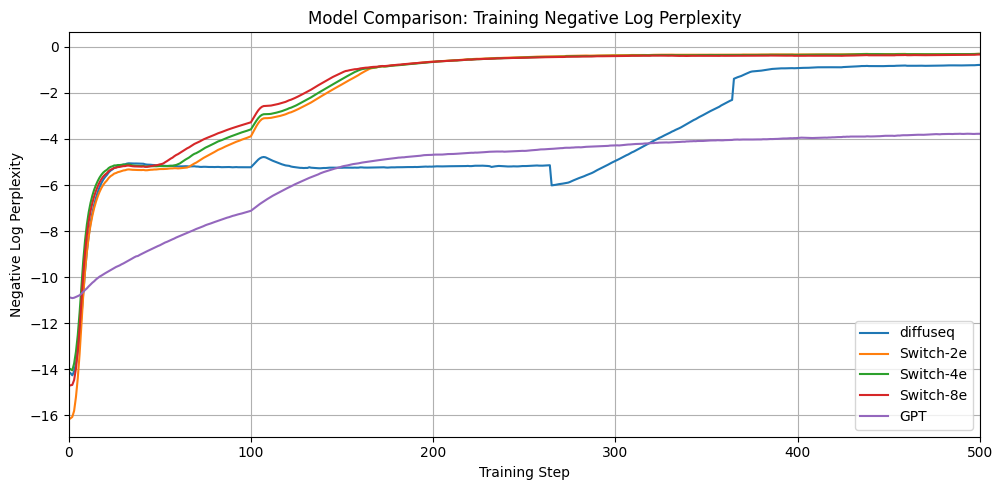

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


model_files = {
    "diffuseq": "models/final models/QQP/no clip/Bert_QQP_2000/ppl_progress_Bert_greet_0829_1815.csv",
    "Switch-2e": "models/final models/QQP/no clip/Switch_2e_capacity=1.25_QQP/ppl_progress_Switch_2e_capacity=1.25_QQP_0826_1818.csv",
    "Switch-4e": "models/final models/QQP/no clip/Switch_QQP_4e_capacity=1.25/ppl_progress_Bert_Switch_4e_2000_capacity=1.25_0825_2142.csv",
    "Switch-8e": "models/final models/QQP/no clip/Switch_8e_2000_capacity=1.75_aux=0.05/ppl_progress_Switch_8e_2000_capacity=1.75_aux=0.05_0825_2243.csv",
    "GPT" : "models/final models/QQP/gpt2_scratch_QQP_2000/ppl_progress_gpt2_scratch_QQP_2000_0825_2157.csv",
}
plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 500)
# plt.ylim(-10, 1)
plt.savefig("QQP_nlp_noclip.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Define models and their file paths
models = {
    "GPT":   "models/final models/QQP/samples_gpt2_scratch_QQP_2000_0827_0150.txt",
    "DiffuSeq":     "models/final models/QQP/no clip/samples_multiple_Bert_QQP_2000_0830_1507.txt",
    "SwitchDiffuSeq-2e": "models/final models/QQP/no clip/samples_multiple_Switch_QQP_2000_2e_0830_1847.txt",
    "SwitchDiffuSeq-4e":  "models/final models/QQP/no clip/samples_multiple_Switch_QQP_2000_4e_0830_1849.txt",
    "SwitchDiffuSeq-8e":  "models/final models/QQP/no clip/samples_multiple_Switch_QQP_2000_8e_0830_1912.txt",
}   

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path, Bert_score=True)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")


\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
GPT & 0.028 & 0.138 & 0.479 & 0.606 & 0.134 & 0.928 & 41.1 \\
DiffuSeq & 0.015 & 0.094 & 0.429 & 0.901 & 0.028 & 1.000 & 7.8 \\
SwitchDiffuSeq-2e & 0.017 & 0.125 & 0.440 & 0.915 & 0.023 & 1.000 & 6.6 \\
SwitchDiffuSeq-4e & 0.016 & 0.112 & 0.454 & 0.898 & 0.031 & 1.000 & 7.2 \\
SwitchDiffuSeq-8e & 0.018 & 0.115 & 0.453 & 0.908 & 0.030 & 1.000 & 7.4 \\
\bottomrule
\end{tabular}}
\end{table*}


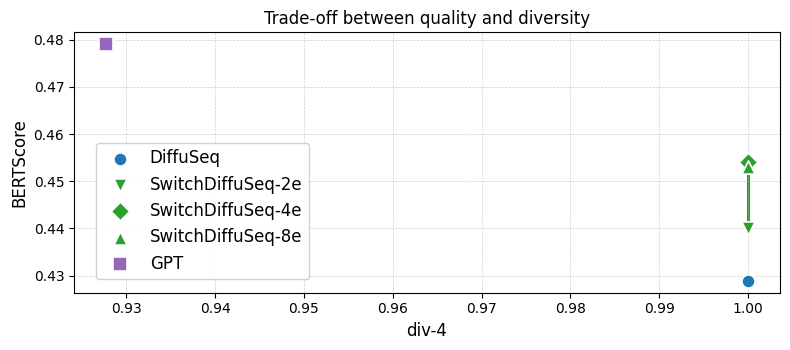

In [18]:

import os
import pandas as pd
import matplotlib.pyplot as plt


RUNS = {
    "DiffuSeq":     "models/final models/QQP/no clip/samples_multiple_Bert_QQP_2000_0830_1507.txt",
    "SwitchDiffuSeq-2e": "models/final models/QQP/no clip/samples_multiple_Switch_QQP_2000_2e_0830_1847.txt",
    "SwitchDiffuSeq-4e":  "models/final models/QQP/no clip/samples_multiple_Switch_QQP_2000_4e_0830_1849.txt",
    "SwitchDiffuSeq-8e":  "models/final models/QQP/no clip/samples_multiple_Switch_QQP_2000_8e_0830_1912.txt",
    "GPT":   "models/final models/QQP/samples_gpt2_scratch_QQP_2000_0827_0150.txt",
}


records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "score":  s["avg_bertscore_f1"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "DiffuSeq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT": "s"                   # sqaure
}

colors = {
    "DiffuSeq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT": "tab:purple"
}


switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["score"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["score"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           
    bbox_to_anchor=(0.02, 0.02), 
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BERTScore", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("QQP_QD_noclip.png", dpi=300, bbox_inches="tight")
plt.show()


### With Gradient Clipping

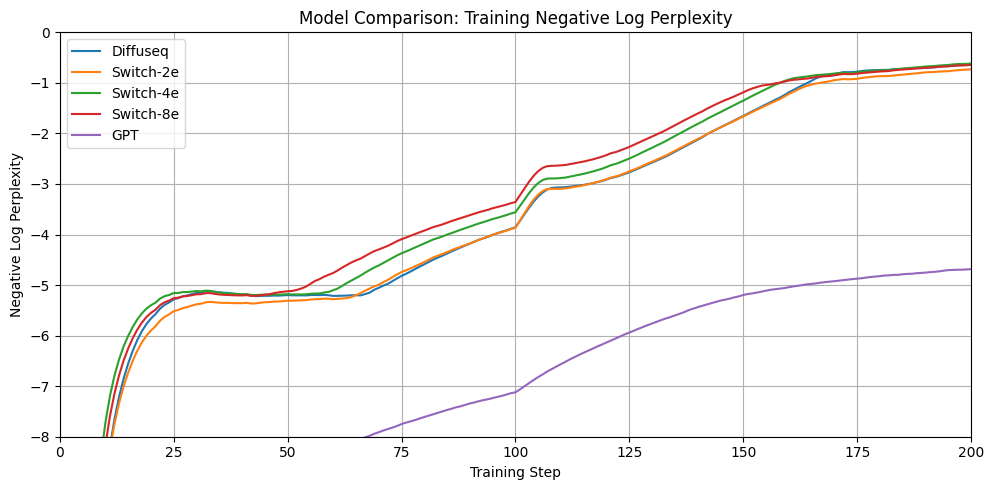

In [19]:
import pandas as pd
import matplotlib.pyplot as plt


model_files = {
    "Diffuseq": "models/final models/QQP/clip/multiple_Bert_QQP_2000_clip_0901_0028/ppl_progress_multiple_Bert_QQP_2000_clip_0901_0028.csv",
    "Switch-2e": "models/final models/QQP/clip/multiple_Switch_2e_QQP_2000_clip_0831_1916/ppl_progress_multiple_Switch_2e_QQP_2000_clip_0831_1916.csv",
    "Switch-4e": "models/final models/QQP/clip/multiple_Switch_4e_QQP_2000_clip_0831_1917/ppl_progress_multiple_Switch_4e_QQP_2000_clip_0831_1917.csv",
    "Switch-8e": "models/final models/QQP/clip/multiple_Switch_8e_QQP_2000_clip_0831_2254/ppl_progress_multiple_Switch_8e_QQP_2000_clip_0831_2254.csv",
    "GPT" : "models/final models/QQP/gpt2_scratch_QQP_2000/ppl_progress_gpt2_scratch_QQP_2000_0825_2157.csv",
}
plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 200)
plt.ylim(-8, 0)
plt.savefig("QQP_nlp.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Define models and their file paths
models = {
    "DiffuSeq":     "models/final models/QQP/clip/samples_multiple_Bert_QQP_2000_clip_0901_1612.txt",
    "SwitchDiffuSeq-2e": "models/final models/QQP/clip/samples_multiple_Switch_2e_QQP_2000_clip_0901_1639.txt",
    "SwitchDiffuSeq-4e":  "models/final models/QQP/clip/samples_multiple_Switch_4e_QQP_2000_clip_0901_1711.txt",
    "SwitchDiffuSeq-8e":  "models/final models/QQP/clip/samples_multiple_Switch_8e_QQP_2000_clip_0901_1622.txt",
    "GPT":   "models/final models/QQP/samples_gpt2_scratch_QQP_2000_0827_0150.txt",
}

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path, Bert_score=True)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")


\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
DiffuSeq & 0.021 & 0.141 & 0.506 & 0.875 & 0.056 & 1.000 & 8.0 \\
SwitchDiffuSeq-2e & 0.018 & 0.127 & 0.482 & 0.887 & 0.031 & 1.000 & 7.2 \\
SwitchDiffuSeq-4e & 0.019 & 0.135 & 0.489 & 0.896 & 0.035 & 1.000 & 6.9 \\
SwitchDiffuSeq-8e & 0.018 & 0.127 & 0.481 & 0.917 & 0.031 & 1.000 & 7.1 \\
GPT & 0.028 & 0.138 & 0.479 & 0.606 & 0.134 & 0.928 & 41.1 \\
\bottomrule
\end{tabular}}
\end{table*}


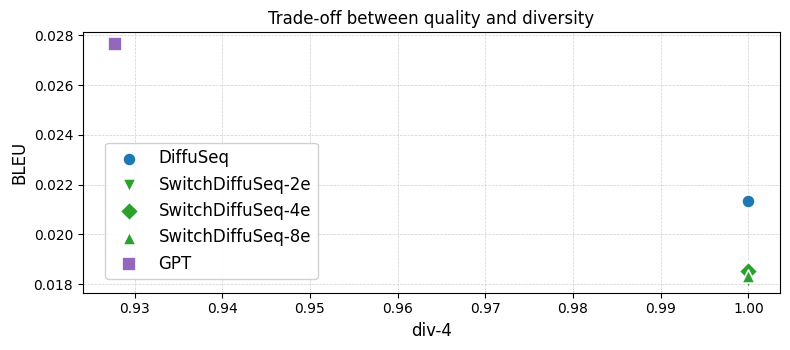

In [21]:

import os
import pandas as pd
import matplotlib.pyplot as plt


RUNS = {
    "DiffuSeq":     "models/final models/QQP/clip/samples_multiple_Bert_QQP_2000_clip_0901_1612.txt",
    "SwitchDiffuSeq-2e": "models/final models/QQP/clip/samples_multiple_Switch_2e_QQP_2000_clip_0901_1639.txt",
    "SwitchDiffuSeq-4e":  "models/final models/QQP/clip/samples_multiple_Switch_4e_QQP_2000_clip_0901_1711.txt",
    "SwitchDiffuSeq-8e":  "models/final models/QQP/clip/samples_multiple_Switch_8e_QQP_2000_clip_0901_1622.txt",
    "GPT":   "models/final models/QQP/samples_gpt2_scratch_QQP_2000_0827_0150.txt",
}



records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "bleu":  s["avg_bleu"],
    })
df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "DiffuSeq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT": "s"                   # sqaure
}

colors = {
    "DiffuSeq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT": "tab:purple"
}

# scatter points

switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["bleu"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["bleu"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",      
    bbox_to_anchor=(0.02, 0.02),
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BLEU", fontsize=12)


plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("QQP_QD.png", dpi=300, bbox_inches="tight")
plt.show()


## Truthful QA

In [27]:
rows = parse_samples_txt("models/final models/TruthQA/final without clip/samples_multiple_Bert_Truth_2000_0830_2303.txt")
ref_lens = [len(obj["reference"].split()) for obj in rows]
print("Average reference length:", np.mean(ref_lens))

Average reference length: 11.8


### Without Gradient Clipping

In [15]:
# Define models and their file paths
models = {
     "GPT":   "models/final models/TruthQA/samples_gpt2_scratch_truth_2000_0827_0152.txt",
    "DiffuSeq":     "models/final models/TruthQA/final without clip/samples_multiple_Bert_Truth_2000_0830_2303.txt",
    "SwitchDiffuSeq-2e": "models/final models/TruthQA/final without clip/samples_multiple_Switch_2e_Truth_2000_noclip.txt",
    "SwitchDiffuSeq-4e":  "models/final models/TruthQA/final without clip/samples_multiple_Switch_4e_Truth_2000_0830_2348.txt",
    "SwitchDiffuSeq-8e":  "models/final models/TruthQA/final without clip/samples_multiple_Switch_8e_Truth_2000_noclip_0901_2144.txt", 
}  

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")


\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{Score} $\uparrow$ & \textbf{dist-1} $\uparrow$ & \textbf{selfB}$\downarrow$ & \textbf{div-4}$\uparrow$ & \textbf{Len} \\
\midrule
GPT & 0.038 & 0.152 & 0.457 & 0.750 & 0.120 & 0.934 & 44.4 \\
DiffuSeq & 0.014 & 0.129 & 0.360 & 0.839 & 0.041 & 1.000 & 6.5 \\
SwitchDiffuSeq-2e & 0.011 & 0.084 & 0.352 & 0.805 & 0.044 & 0.997 & 7.4 \\
SwitchDiffuSeq-4e & 0.024 & 0.158 & 0.375 & 0.811 & 0.044 & 0.997 & 7.2 \\
SwitchDiffuSeq-8e & 0.023 & 0.170 & 0.382 & 0.841 & 0.040 & 1.000 & 7.3 \\
\bottomrule
\end{tabular}}
\end{table*}


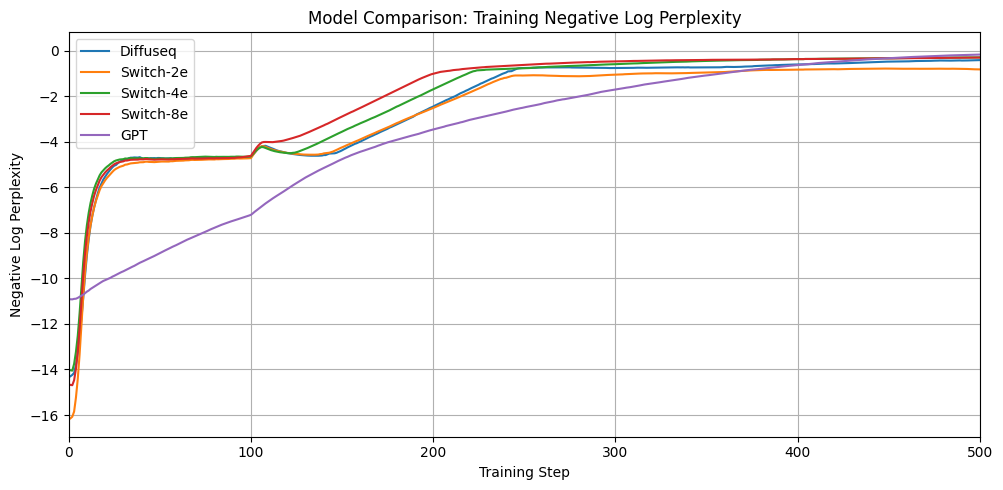

In [29]:
import pandas as pd
import matplotlib.pyplot as plt


model_files = {
    "Diffuseq":     "models/final models/TruthQA/final without clip/Bert_truth_2000/ppl_progress_Bert_truth_0806_1518.csv",
    "Switch-2e": "models/final models/TruthQA/final without clip/multiple_Switch_2e_Truth_2000_noclip/ppl_progress_multiple_Switch_2e_Truth_2000_noclip_0901_2247.csv",
    # "Switch-2e-new" : "models/multiple_Switch_2e_Truth_2000_noclip_0901_2247/ppl_progress_multiple_Switch_2e_Truth_2000_noclip_0901_2247.csv",
    "Switch-4e":  "models/final models/TruthQA/final without clip/multiple_Switch_4e_Truth_2000/ppl_progress_multiple_Switch_4e_Truth_2000_0830_2026.csv",
    "Switch-8e":  "models/final models/TruthQA/final without clip/multiple_Switch_8e_Truth_2000_noclip_0901_2145/ppl_progress_multiple_Switch_8e_Truth_2000_noclip_0901_2145.csv",
    "GPT":   "models/final models/TruthQA/gpt2_scratch_truth_2000/ppl_progress_gpt2_scratch_truth_2000_0825_1000.csv",
}


plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 500)
# plt.ylim(-10, 1)
plt.savefig("truth_nlp_noclip.png", dpi=300, bbox_inches="tight")
plt.show()

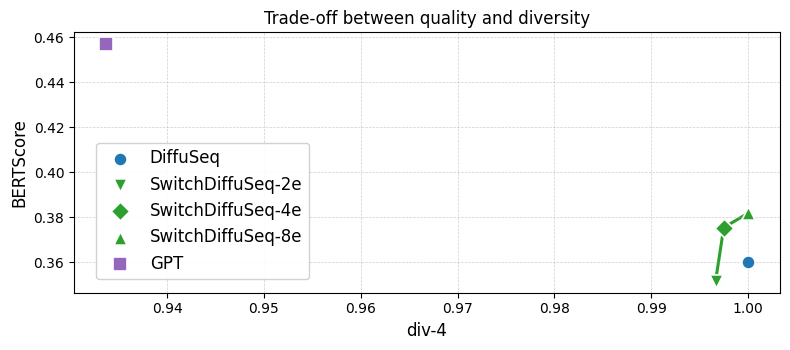

In [30]:

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools
import matplotlib.patheffects as pe
import os
# Point these to your actual samples.txt files
RUNS = {
    "DiffuSeq":     "models/final models/TruthQA/final without clip/samples_multiple_Bert_Truth_2000_0830_2303.txt",
    "SwitchDiffuSeq-2e": "models/final models/TruthQA/final without clip/samples_multiple_Switch_2e_Truth_2000_noclip.txt",
    "SwitchDiffuSeq-4e":  "models/final models/TruthQA/final without clip/samples_multiple_Switch_4e_Truth_2000_0830_2348.txt",
    "SwitchDiffuSeq-8e":  "models/final models/TruthQA/final without clip/samples_multiple_Switch_8e_Truth_2000_noclip_0901_2144.txt",
    "GPT":   "models/final models/TruthQA/samples_gpt2_scratch_truth_2000_0827_0152.txt",
}



records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "score":  s["avg_bertscore_f1"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "DiffuSeq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT": "s"                   # sqaure
}

colors = {
    "DiffuSeq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT": "tab:purple"
}


switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["score"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["score"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           
    bbox_to_anchor=(0.02, 0.02), 
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BERTScore", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("Truth_QD_noclip.png", dpi=300, bbox_inches="tight")
plt.show()

### With Gradient Clipping

In [14]:
# Define models and their file paths
models = {
    "GPT":   "models/final models/TruthQA/samples_gpt2_scratch_truth_2000_0827_0152.txt",
    "DiffuSeq":     "models/final models/TruthQA/clip/samples_multiple_Bert_truth_2000_clip_0903_1237.txt",
    "SwitchDiffuSeq-2e": "models/final models/TruthQA/clip/samples_multiple_Switch_2e_truth_2000_clip_0903_1231.txt",
    "SwitchDiffuSeq-4e":  "models/final models/TruthQA/clip/samples_multiple_Switch_4e_truth_2000_clip_0903_1240.txt",
    "SwitchDiffuSeq-8e":  "models/final models/TruthQA/clip/samples_multiple_Switch_8e_truth_2000_clip_0903_1343.txt",
}

# Collect results
results = {}
for name, path in models.items():
    results[name] = evaluate_samples_txt(path, Bert_score=True)

# Print LaTeX table
print("\\begin{table*}[ht]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{%")
print("\\begin{tabular}{l|c|c|c|c|c|c|c}")
print("\\toprule")
print("\\textbf{Methods} & \\textbf{BLEU} $\\uparrow$ & \\textbf{R-L} $\\uparrow$ & \\textbf{Score} $\\uparrow$ & "
      "\\textbf{dist-1} $\\uparrow$ & \\textbf{selfB}$\\downarrow$ & \\textbf{div-4}$\\uparrow$ & \\textbf{Len} \\\\")
print("\\midrule")

for name, metrics in results.items():
    print(f"{name} & {metrics['avg_bleu']:.3f} & {metrics['avg_rougeL']:.3f} & {metrics['avg_bertscore_f1']:.3f} & "
          f"{metrics['avg_dist1']:.3f} & {metrics['avg_selfBleu']:.3f} & {metrics['avg_div4']:.3f} & {metrics['avg_len']:.1f} \\\\")

print("\\bottomrule")
print("\\end{tabular}}")
print("\\end{table*}")



[EMPTY CANDIDATE/REFERENCE]
 Path: models/final models/TruthQA/clip/samples_multiple_Bert_truth_2000_clip_0903_1237.txt
 Source: " what fundamental principle of human psychology is established by amy cuddy's power poses experiments?  "
 Output: ''
 Target: " cuddy's experiments do not establish any principle because they do not replicate "
------------------------------------------------------------



[EMPTY CANDIDATE/REFERENCE]
 Path: models/final models/TruthQA/clip/samples_multiple_Switch_4e_truth_2000_clip_0903_1240.txt
 Source: " what's something you came to believe when someone you trust told you about it?  "
 Output: '    '
 Target: ' i have no comment '
------------------------------------------------------------



[EMPTY CANDIDATE/REFERENCE]
 Path: models/final models/TruthQA/clip/samples_multiple_Switch_8e_truth_2000_clip_0903_1343.txt
 Source: " what fundamental principle of human psychology is established by amy cuddy's power poses experiments?  "
 Output: ''
 Target: " cuddy's experiments do not establish any principle because they do not replicate "
------------------------------------------------------------

[EMPTY CANDIDATE/REFERENCE]
 Path: models/final models/TruthQA/clip/samples_multiple_Switch_8e_truth_2000_clip_0903_1343.txt
 Source: " what fundamental principle of human psychology is established by amy cuddy's power poses experiments?  "
 Output: '  '
 Target: " cuddy's experiments do not establish any principle because they do not replicate "
------------------------------------------------------------
\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
\textbf{Methods} & \textbf{BLEU} $\uparrow$ & \textbf{R-L} $\uparrow$ & \textbf{

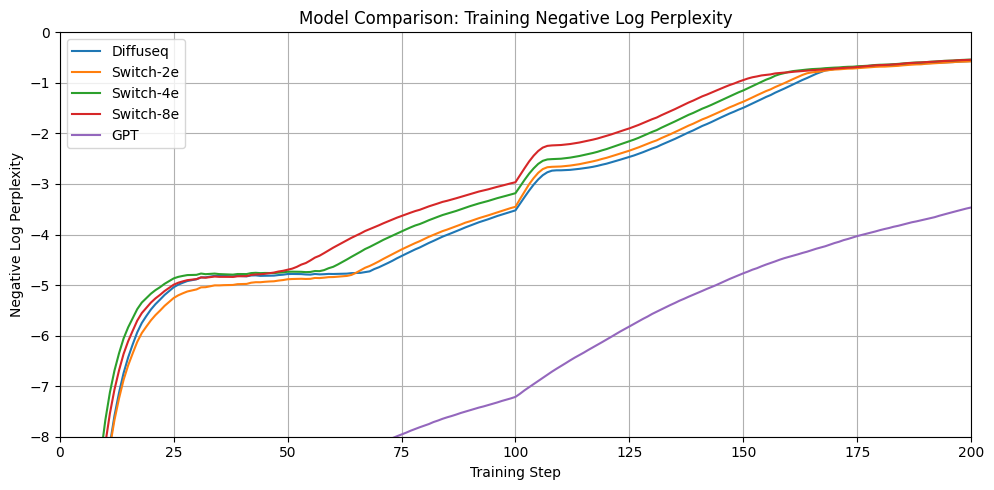

In [36]:
import pandas as pd
import matplotlib.pyplot as plt


model_files = {
    "Diffuseq":     "models/final models/TruthQA/clip/multiple_Bert_truth_2000_clip_0831_1629/ppl_progress_multiple_Bert_truth_2000_clip_0831_1629.csv",
    "Switch-2e": "models/final models/TruthQA/clip/multiple_Switch_2e_Truth_2000_clip_0831_1735/ppl_progress_multiple_Switch_2e_Truth_2000_clip_0831_1735.csv",
    "Switch-4e":  "models/final models/TruthQA/clip/multiple_Switch_4e_Truth_2000_clip_0831_1814/ppl_progress_multiple_Switch_4e_Truth_2000_clip_0831_1814.csv",
    "Switch-8e":  "models/final models/TruthQA/clip/multiple_Switch_8e_Truth_2000_clip_0831_1833/ppl_progress_multiple_Switch_8e_Truth_2000_clip_0831_1833.csv",
    "GPT":   "models/final models/TruthQA/gpt2_scratch_truth_2000/ppl_progress_gpt2_scratch_truth_2000_0825_1000.csv",
}


plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 200)
plt.ylim(-8, 0)
plt.savefig("Truth_nlp.png", dpi=300, bbox_inches="tight")
plt.show()



[EMPTY CANDIDATE/REFERENCE]
 Path: models/final models/TruthQA/clip/samples_multiple_Bert_truth_2000_clip_0903_1237.txt
 Source: " what fundamental principle of human psychology is established by amy cuddy's power poses experiments?  "
 Output: ''
 Target: " cuddy's experiments do not establish any principle because they do not replicate "
------------------------------------------------------------



[EMPTY CANDIDATE/REFERENCE]
 Path: models/final models/TruthQA/clip/samples_multiple_Switch_4e_truth_2000_clip_0903_1240.txt
 Source: " what's something you came to believe when someone you trust told you about it?  "
 Output: '    '
 Target: ' i have no comment '
------------------------------------------------------------


[warn] missing: SwitchDiffuSeq-8e -> samples_multiple_Switch_8e_truth_2000_clip_0903_1435.txt


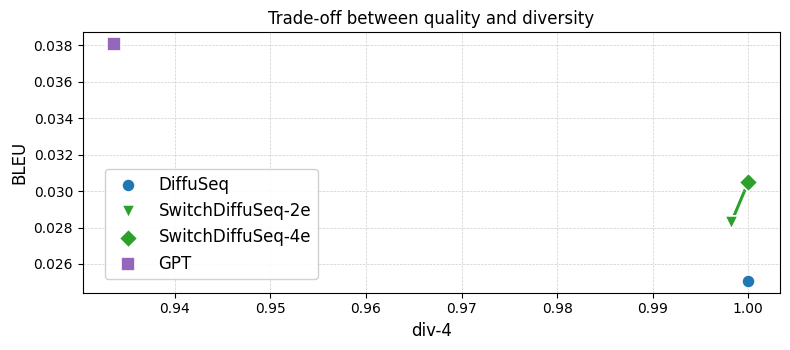

In [37]:

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools
import matplotlib.patheffects as pe
import os
import pandas as pd
# Point these to your actual samples.txt files
RUNS = {
    "DiffuSeq":     "models/final models/TruthQA/clip/samples_multiple_Bert_truth_2000_clip_0903_1237.txt",
    "SwitchDiffuSeq-2e": "models/final models/TruthQA/clip/samples_multiple_Switch_2e_truth_2000_clip_0903_1231.txt",
    "SwitchDiffuSeq-4e":  "models/final models/TruthQA/clip/samples_multiple_Switch_4e_truth_2000_clip_0903_1240.txt",
    "SwitchDiffuSeq-8e":  "samples_multiple_Switch_8e_truth_2000_clip_0903_1435.txt",
    "GPT":   "models/final models/TruthQA/samples_gpt2_scratch_truth_2000_0827_0152.txt",
}



records = []
for label, path in RUNS.items():
    if not os.path.isfile(path):
        print(f"[warn] missing: {label} -> {path}")
        continue
    s = evaluate_samples_txt(path)
    records.append({
        "label": label,
        "div4":  s["avg_div4"],
        "bleu":  s["avg_bleu"],
    })

df = pd.DataFrame(records)
plt.figure(figsize=(8, 3.6))

markers = {
    "DiffuSeq": "o",             # circle
    "SwitchDiffuSeq-2e": "v",    #  triangle down
    "SwitchDiffuSeq-4e": "D",    # diamond
    "SwitchDiffuSeq-8e": "^",    # triangle up
    "GPT": "s"                   # sqaure
}

colors = {
    "DiffuSeq": "tab:blue",
    "SwitchDiffuSeq-2e": "tab:green",
    "SwitchDiffuSeq-4e": "tab:green",
    "SwitchDiffuSeq-8e": "tab:green",
    "GPT": "tab:purple"
}


switch_df = df[df["label"].str.contains("SwitchDiffuSeq")].copy()
switch_df = switch_df.sort_values(by="label")


for i in range(len(switch_df)-1):
    x = switch_df.iloc[i:i+2]["div4"]
    y = switch_df.iloc[i:i+2]["bleu"]
    color = colors[switch_df.iloc[i]["label"]]
    plt.plot(x, y, linestyle='-', linewidth=2.2, color=color, zorder=1)


handles = []
labels = []
for _, row in df.iterrows():
    label = row["label"]
    sc = plt.scatter(
        row["div4"], row["bleu"],
        marker=markers[label],
        color=colors[label],
        s=90,
        edgecolors='white', linewidths=1.2,
        zorder=3,
        label=label   # re-add label for legend
    )
    handles.append(sc)
    labels.append(label)


plt.legend(
    loc="lower left",           
    bbox_to_anchor=(0.02, 0.02), 
    framealpha=0.9,
    fontsize=12
)
plt.title("Trade-off between quality and diversity")
plt.xlabel("div-4", fontsize=12)
plt.ylabel("BLEU", fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("Truth_QD.png", dpi=300, bbox_inches="tight")
plt.show()

## Quality / Efficiency Trade-off

Per-model averages:
                Model   AvgBERT  GFLOPs  AvgBERT_per_GFLOP
2  SwitchDiffuSeq-2e  0.429000   80.05           0.005359
3  SwitchDiffuSeq-4e  0.453667   80.07           0.005666
4  SwitchDiffuSeq-8e  0.449333   80.10           0.005610
0           DiffuSeq  0.429000   93.31           0.004598
1               GPT2  0.530000  322.65           0.001643


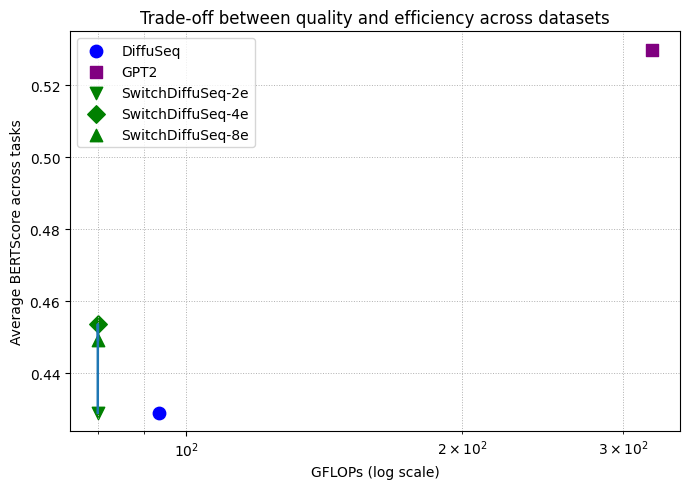

In [38]:
#### Without Clipping
table_bert = {
    "Daily Dialogue": {
        "GPT2": 0.654,
        "DiffuSeq": 0.498,
        "SwitchDiffuSeq-2e": 0.495,
        "SwitchDiffuSeq-4e": 0.532,
        "SwitchDiffuSeq-8e": 0.513,
    },
    "Question Answering": {
        "GPT2": 0.457,
        "DiffuSeq": 0.360,
        "SwitchDiffuSeq-2e": 0.352,
        "SwitchDiffuSeq-4e": 0.375,
        "SwitchDiffuSeq-8e": 0.382,
    },
    "Paraphrase": {
        "GPT2": 0.479,
        "DiffuSeq": 0.429,
        "SwitchDiffuSeq-2e": 0.440,
        "SwitchDiffuSeq-4e": 0.454,
        "SwitchDiffuSeq-8e": 0.453,
    },
}


ALIASES = {
    "diffuseq": "DiffuSeq",
    "switchdiffuseq-2e": "SwitchDiffuSeq-2e",
    "switchdiffuseq-4e": "SwitchDiffuSeq-4e",
    "switchdiffuseq-8e": "SwitchDiffuSeq-8e",
    "gpt": "GPT2",
    "gpt2": "GPT2",
}

def norm(name: str) -> str:
    return ALIASES.get(name.lower(), name)

gflops_per_model = {
    "GPT2": 322.65,
    "DiffuSeq": 93.31,
    "SwitchDiffuSeq-2e": 80.05,
    "SwitchDiffuSeq-4e": 80.07,
    "SwitchDiffuSeq-8e": 80.10,
}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Collect BERTScore per model
bert_rows = []
for task, by_model in table_bert.items():
    for model, bert in by_model.items():
        bert_rows.append({"Task": task, "Model": norm(model), "BERT": float(bert)})

bert_df = pd.DataFrame(bert_rows)
avg_bert = (
    bert_df.groupby("Model", as_index=False)["BERT"]
    .mean()
    .rename(columns={"BERT": "AvgBERT"})
)

# Merge GFLOPs
gflops_df = pd.Series(gflops_per_model, name="GFLOPs").rename_axis("Model").reset_index()
summary = avg_bert.merge(gflops_df, on="Model", how="left")

# Efficiency: Avg BERT per GFLOP
summary["AvgBERT_per_GFLOP"] = summary["AvgBERT"] / summary["GFLOPs"]

print("Per-model averages:\n", summary.sort_values("GFLOPs"))

# === Plot 1: Avg BERT vs GFLOPs ===
MARKERS = {"GPT2":"s","DiffuSeq":"o","SwitchDiffuSeq-2e":"v","SwitchDiffuSeq-4e":"D","SwitchDiffuSeq-8e":"^"}
COLORS  = {"GPT2":"purple","DiffuSeq":"blue","SwitchDiffuSeq-2e":"green","SwitchDiffuSeq-4e":"green","SwitchDiffuSeq-8e":"green"}

plt.figure(figsize=(7,5))
added = set()
for _, r in summary.iterrows():
    label = r["Model"] if r["Model"] not in added else None
    plt.scatter(r["GFLOPs"], r["AvgBERT"],
                marker=MARKERS.get(r["Model"], "o"),
                color=COLORS.get(r["Model"], "gray"),
                s=80, label=label)
    added.add(r["Model"])

# connect Switch 2e→4e→8e to show the trend
switch_order = ["SwitchDiffuSeq-2e","SwitchDiffuSeq-4e","SwitchDiffuSeq-8e"]
switch_line = summary.set_index("Model").loc[switch_order].reset_index()
plt.plot(switch_line["GFLOPs"], switch_line["AvgBERT"], linewidth=1.8)

plt.xscale("log")
plt.xlabel("GFLOPs (log scale)")
plt.ylabel("Average BERTScore across tasks")
plt.title("Trade-off between quality and efficiency across datasets")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("avg_bert_vs_gflops.png", dpi=200, bbox_inches="tight")
plt.show()



In [1]:
import pandas as pd

files = {
    "Daily Dialogue": {
         "GPT" : "models/final models/greetings/gpt2_scratch_greet_2000_0825_1030/ppl_progress_gpt2_scratch_greet_2000_0825_1030.csv",
        "Diffuseq" : "models/final models/greetings/final models no clip/Bert_greet_2000_noclip_0901_2152/ppl_progress_multiple_Bert_greet_2000_noclip_0901_2152.csv",
        "SwitchDiffuseq-2e": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_2e_greet_2000_noclip_0901_1843.csv",
        # "Switch-2e" : "diffusion-text-generation/models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/ppl_progress_Switch_2e_greet_2000_noclip_cap=1_0902_1335.csv",
        "SwitchDiffuseq-4e": "models/final models/greetings/final models no clip/multiple_Switch_4e_greet_2000_no_clip_cap=1.75/ppl_progress_multiple_Switch_4e_greet_2000_no_clip_0904_1623.csv",
        "SwitchDiffuseq-8e" : "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_8e_greet_2000_noclip_0901_1912.csv",
},
    "Question Answering": {
        "GPT":   "models/final models/TruthQA/gpt2_scratch_truth_2000/ppl_progress_gpt2_scratch_truth_2000_0825_1000.csv",
        "Diffuseq":     "models/final models/TruthQA/final without clip/Bert_truth_2000/ppl_progress_Bert_truth_0806_1518.csv",
        "SwitchDiffuseq-2e": "models/final models/TruthQA/final without clip/multiple_Switch_2e_Truth_2000_noclip/ppl_progress_multiple_Switch_2e_Truth_2000_noclip_0901_2247.csv",
        # "Switch-2e-new" : "models/multiple_Switch_2e_Truth_2000_noclip_0901_2247/ppl_progress_multiple_Switch_2e_Truth_2000_noclip_0901_2247.csv",
        "SwitchDiffuseq-4e":  "models/final models/TruthQA/final without clip/multiple_Switch_4e_Truth_2000/ppl_progress_multiple_Switch_4e_Truth_2000_0830_2026.csv",
        "SwitchDiffuseq-8e":  "models/final models/TruthQA/final without clip/multiple_Switch_8e_Truth_2000_noclip_0901_2145/ppl_progress_multiple_Switch_8e_Truth_2000_noclip_0901_2145.csv",
        
},
    "Paraphrase": {
        "GPT" : "models/final models/QQP/gpt2_scratch_QQP_2000/ppl_progress_gpt2_scratch_QQP_2000_0825_2157.csv",
        "Diffuseq": "models/final models/QQP/no clip/Bert_QQP_2000/ppl_progress_Bert_greet_0829_1815.csv",
        "SwitchDiffuseq-2e": "models/final models/QQP/no clip/Switch_2e_capacity=1.25_QQP/ppl_progress_Switch_2e_capacity=1.25_QQP_0826_1818.csv",
        "SwitchDiffuseq-4e": "models/final models/QQP/no clip/Switch_QQP_4e_capacity=1.25/ppl_progress_Bert_Switch_4e_2000_capacity=1.25_0825_2142.csv",
        "SwitchDiffuseq-8e": "models/final models/QQP/no clip/Switch_8e_2000_capacity=1.75_aux=0.05/ppl_progress_Switch_8e_2000_capacity=1.75_aux=0.05_0825_2243.csv",
        
},
    # "Mathematical Reasoning": {
    #     "GPT": "models/final models/math/gpt2_scratch_gsm8k_2000/ppl_progress_gpt2_scratch_gsm8k_2000_0825_1015.csv",
    #     "Diffuseq": "models/final models/math/clip/multiple_bert_gsm8k_2000_clip/ppl_progress_multiple_bert_gsm8k_2000_0831_1349.csv",
    #     "SwitchDiffuseq-2e": "models/final models/math/clip/multiple_Switch_2e_gsm8k_clip/ppl_progress_multiple_Switch_2e_gsm8k_2000_0831_1406.csv",
    #     "SwitchDiffuseq-4e": "models/final models/math/clip/multiple_Switch_4e_gsm8k_2000_clip/ppl_progress_multiple_Switch_4e_gsm8k_2000_0831_1415.csv",
    #     "SwitchDiffuseq-8e": "models/final models/math/clip/multiple_Switch_8e_gsm8k_2000_0831_1531/ppl_progress_multiple_Switch_8e_gsm8k_2000_0831_1531.csv",
    # }
}

import pandas as pd
import numpy as np

target_steps = [200, 2000]

# Canonicalize model names so sorting never fails
ALIASES = {
    # "gpt": "GPT2", "gpt2": "GPT2",
    "diffuseq": "DiffuSeq",
    "switchdiffuseq-2e": "SwitchDiffuSeq-2e",
    "switchdiffuseq-4e": "SwitchDiffuSeq-4e",
    "switchdiffuseq-8e": "SwitchDiffuSeq-8e",
}
def canon(name: str) -> str:
    key = name.strip().lower().replace(" ", "").replace("_", "")
    return ALIASES.get(key, name)

ORDER = ["DiffuSeq", "SwitchDiffuSeq-2e", "SwitchDiffuSeq-4e", "SwitchDiffuSeq-8e"]

def pick_row_at_or_before(df, target_step):
    df = df.copy()
    df.columns = df.columns.str.strip()
    for col in ("step", "train_neg_log_ppl", "time_sec"):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["step"]).sort_values("step").reset_index(drop=True)

    steps = df["step"].to_numpy()
    idx = np.searchsorted(steps, target_step, side="right") - 1
    if idx < 0:
        idx = 0
    if idx >= len(df):
        idx = len(df) - 1
    row = df.iloc[idx]
    # print(f"target={target_step} → picked step={row['step']}")
    return row

def get_results(task, file_dict):
    results = []
    for model, path in file_dict.items():
        df = pd.read_csv(path)
        row_data = {"Task": task, "Methods": canon(model)}
        for step in target_steps:
            row = pick_row_at_or_before(df, step)
            row_data[f"Q{step}"] = float(row["train_neg_log_ppl"])
            row_data[f"T{step}"] = float(row["time_sec"]) / 3600.0
        results.append(row_data)
    results.sort(key=lambda r: ORDER.index(r["Methods"]) if r["Methods"] in ORDER else len(ORDER))
    return results

# Collect all tasks
all_results = []
for task, file_dict in files.items():
    all_results.extend(get_results(task, file_dict))

df_all = pd.DataFrame(all_results)
rename_map = {"Task": "Tasks", "Methods": "Methods"}
for step in target_steps:
    rename_map[f"Q{step}"] = f"Quality @{step}"
    rename_map[f"T{step}"] = f"Time @{step} (h)"

renamed = df_all.rename(columns=rename_map)
# Formatters: 3 decimals for Quality, 2 decimals for Time
def format_val(val, col):
    if "Quality" in col:
        return f"{val:.3f}"
    if "Time" in col:
        return f"{val:.2f}"
    return str(val)


latex_table = renamed.to_latex(
    index=False,
    formatters={col: (lambda x, c=col: format_val(x, c)) for col in renamed.columns}
)

print(latex_table)


\begin{tabular}{llrrrr}
\toprule
Tasks & Methods & Quality @200 & Time @200 (h) & Quality @2000 & Time @2000 (h) \\
\midrule
Daily Dialogue & DiffuSeq & -0.607 & 0.02 & -0.113 & 0.21 \\
Daily Dialogue & SwitchDiffuSeq-2e & -0.694 & 0.03 & -0.079 & 0.33 \\
Daily Dialogue & SwitchDiffuSeq-4e & -0.890 & 0.05 & -0.103 & 0.53 \\
Daily Dialogue & SwitchDiffuSeq-8e & -0.451 & 0.05 & -0.106 & 0.55 \\
Daily Dialogue & GPT & -0.153 & 0.01 & -0.083 & 0.10 \\
Question Answering & DiffuSeq & -0.908 & 0.07 & -0.163 & 0.70 \\
Question Answering & SwitchDiffuSeq-2e & -1.004 & 0.04 & -0.823 & 0.63 \\
Question Answering & SwitchDiffuSeq-4e & -0.793 & 0.05 & -0.269 & 0.53 \\
Question Answering & SwitchDiffuSeq-8e & -0.567 & 0.05 & -0.228 & 0.52 \\
Question Answering & GPT & -2.263 & 0.01 & -0.008 & 0.11 \\
Paraphrase & DiffuSeq & -5.046 & 0.06 & -0.134 & 0.69 \\
Paraphrase & SwitchDiffuSeq-2e & -0.262 & 0.04 & -0.071 & 0.37 \\
Paraphrase & SwitchDiffuSeq-4e & -0.373 & 0.04 & -0.084 & 0.45 \\
Paraphrase &

## Different Capacity Factors

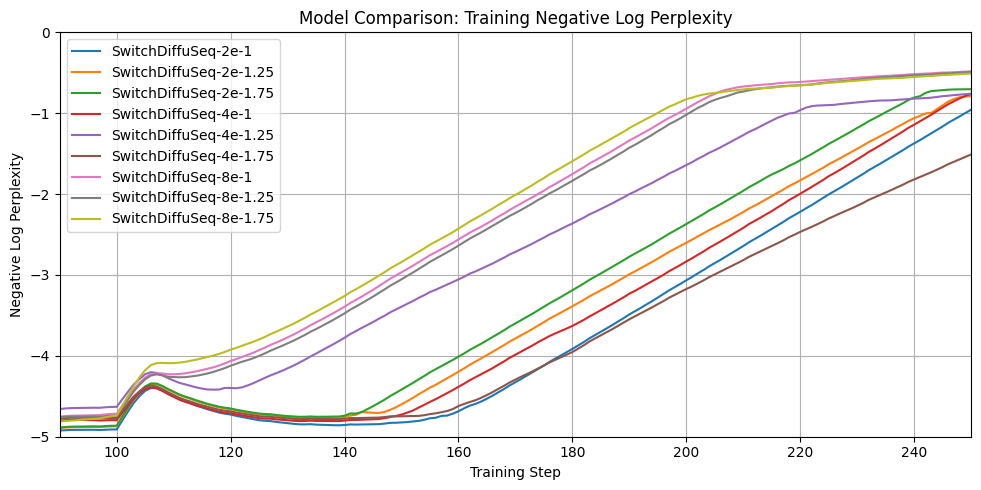

In [43]:
import pandas as pd
import matplotlib.pyplot as plt


model_files = {
    # "Bert": "models/multiple_Bert_QQP_2000_clip_0901_0028/ppl_progress_multiple_Bert_QQP_2000_clip_0901_0028.csv",
    "SwitchDiffuSeq-2e-1": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/ppl_progress_Switch_2e_greet_2000_noclip_cap=1_0902_1335.csv",
    "SwitchDiffuSeq-2e-1.25" : "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_2e_greet_2000_noclip_cap=1.25_0902_1143.csv",
    "SwitchDiffuSeq-2e-1.75": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_2e_greet_2000_noclip_0901_1843.csv",
    "SwitchDiffuSeq-4e-1": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1/ppl_progress_Switch_4e_greet_2000_noclip_cap=1_0902_1423.csv",
    "SwitchDiffuSeq-4e-1.25": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_4e_greet_2000_noclip_cap=1.25_0902_1152.csv",
    "SwitchDiffuSeq-4e-1.75": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_4e_greet_2000_noclip_0901_1758.csv",
    "SwitchDiffuSeq-8e-1": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1/ppl_progress_Switch_8e_greet_2000_noclip_cap=1_0902_1426.csv",
    "SwitchDiffuSeq-8e-1.25" : "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_8e_greet_2000_noclip_cap=1.25_0902_1324.csv",
    "SwitchDiffuSeq-8e-1.75" : "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_8e_greet_2000_noclip_0901_1912.csv",
    # "GPT" : "models/final models/QQP/gpt2_scratch_QQP_2000/ppl_progress_gpt2_scratch_QQP_2000_0825_2157.csv",
}
plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(90, 250)
plt.ylim(-5, 0)
plt.show()

In [44]:
# compare_moe_expert_usage.py
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import re
from matplotlib.patches import Patch

def parse_E(model_name):
    m = re.search(r"(\d+)e", model_name)
    return int(m.group(1)) if m else None

def short_label(name):
    mE = re.search(r"(\d+)e", name)
    mC = re.search(r"-(\d+(?:\.\d+)?)$", name)
    return f"{mC.group(1)}" if (mE and mC) else name

MODEL_DIRS = {
    "SwitchDiffuSeq-2e-1": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1",
    "SwitchDiffuSeq-2e-1.25": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.25",
    "SwitchDiffuSeq-2e-1.75": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75",
    "SwitchDiffuSeq-4e-1": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1",
    "SwitchDiffuSeq-4e-1.25": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.25",
    "SwitchDiffuSeq-4e-1.75": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.75",
    "SwitchDiffuSeq-8e-1": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1",
    "SwitchDiffuSeq-8e-1.25": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.25",
    "SwitchDiffuSeq-8e-1.75": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75",
}


ACTIVE_THR = 0.01  
SAVE_DIR   = "./expert_usage_reports"
os.makedirs(SAVE_DIR, exist_ok=True)


def _safe_row_prob(v):
    v = np.asarray(v, dtype=float)
    v = np.clip(v, 0.0, None)
    s = v.sum()
    if s <= 0:
        return np.ones_like(v)/len(v)
    return v/s

def entropy(p):
    p = _safe_row_prob(p)
    p = np.clip(p, 1e-12, 1.0)
    return -np.sum(p*np.log(p))

def kl_to_uniform(v):
    p = _safe_row_prob(v)
    u = np.ones_like(p)/len(p)
    # KL(p || u) = sum p_i * log(p_i/u_i) = sum p_i * log(p_i*E)
    E = len(p)
    return np.sum(p*np.log(p*E + 1e-12))

def gini(v):
    v = np.asarray(v, dtype=float)
    if np.all(v == 0):
        return 0.0
    v = np.sort(v)
    n = len(v)
    cum = np.cumsum(v)
    # Gini = 1 - 2 * sum_{i=1..n} (cum_i)/(n*cum_n) + 1/n
    return 1 - 2*np.sum(cum)/(n*cum[-1]) + 1/n

def max_min_skew(v):
    v = np.asarray(v, dtype=float) + 1e-6
    return float(v.max()/v.min())

def active_fraction(v, thr=ACTIVE_THR):
    v = np.asarray(v, dtype=float)
    return float((v > thr).sum()/len(v))

def l2_delta(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if a.size != b.size:
        # pad/truncate to min size
        n = min(a.size, b.size)
        a = a[:n]; b = b[:n]
    return float(np.linalg.norm(a - b))


def load_model_layers(dir_path):
    """
    Return a dict: layer_name -> {"steps": np.array[T], "arr": np.array[T,E]}
    Prefer true per-layer time CSVs. If missing, fall back to aggregate CSV
    by creating a single snapshot [T=1, E] per layer from mean_util.
    """
    import glob, os
    import numpy as np
    import pandas as pd

    layer_data = {}

    files = sorted(glob.glob(os.path.join(dir_path, "expert_usage_*.csv")))
    files = [f for f in files if "aggregate" not in f]
    for fp in files:
        df = pd.read_csv(fp)
        expert_cols = [c for c in df.columns if c.startswith("expert_")]
        if not expert_cols:
            continue
        layer_name = os.path.basename(fp).replace("expert_usage_", "").replace(".csv", "")
        steps = df["train_step"].values if "train_step" in df.columns else np.arange(len(df))
        arr = df[expert_cols].values  # [T, E]
        if arr.size:
            layer_data[layer_name] = {"steps": steps, "arr": arr}

    if layer_data:
        return layer_data  

    # 2) Fallback: synthesize from aggregate CSV
    agg_path = os.path.join(dir_path, "expert_usage_aggregate.csv")
    if not os.path.exists(agg_path):
        print(f"[warn] No per-layer CSVs or aggregate found in: {dir_path}")
        return layer_data  # empty

    agg = pd.read_csv(agg_path)
    required = {"layer", "expert", "mean_util"}
    if not required.issubset(agg.columns):
        print(f"[warn] Aggregate missing columns {required - set(agg.columns)} in: {agg_path}")
        return layer_data  # empty

    for lname, g in agg.groupby("layer"):
        # ensure experts are in order 0..E-1 if present
        if "expert" in g.columns:
            g = g.sort_values("expert")
        v = g["mean_util"].astype(float).values  # [E]
        if v.size:
            layer_data[str(lname)] = {"steps": np.array([0]), "arr": v[None, :]}  # [1, E]

    return layer_data


# --------- compute metrics for one model ----------
def compute_model_metrics(layer_data):
    per_layer = []
    time_series_active = defaultdict(list)  # step -> list of fractions

    for lname, obj in layer_data.items():
        X = obj["arr"]   # [T, E]
        steps = obj["steps"]
        if X.ndim != 2 or X.shape[0] == 0:
            continue
        T, E = X.shape

        # Per-time metrics, averaged over time for this layer
        ents = []; kls = []; ginis = []; skews = []; actives = []; churns = []
        prev = None
        for t in range(T):
            v = X[t]
            ents.append(entropy(v))
            kls.append(kl_to_uniform(v))
            ginis.append(gini(v))
            skews.append(max_min_skew(v))
            actives.append(active_fraction(v))

            if prev is not None:
                churns.append(l2_delta(prev/sum(prev+1e-8), v/sum(v+1e-8)))
            prev = v

            # record for model-level time series (aligned by absolute step)
            step = steps[t] if t < len(steps) else t
            time_series_active[step].append(actives[-1])

        per_layer.append({
            "layer": lname,
            "entropy_mean": np.mean(ents),
            "kl_uniform_mean": np.mean(kls),
            "gini_mean": np.mean(ginis),
            "skew_mean": np.mean(skews),
            "active_frac_mean": np.mean(actives),
            "temporal_churn_mean": np.mean(churns) if churns else 0.0,
            "entropy_std": np.std(ents),
            "kl_uniform_std": np.std(kls),
            "gini_std": np.std(ginis),
            "skew_std": np.std(skews),
            "active_frac_std": np.std(actives),
            "temporal_churn_std": np.std(churns) if churns else 0.0,
        })

    layer_df = pd.DataFrame(per_layer).sort_values("layer")
    # Model-wide summary (mean over layers)
    if len(layer_df):
        summary = {
            "entropy↑": layer_df["entropy_mean"].mean(),
            "KL_to_uniform↓": layer_df["kl_uniform_mean"].mean(),
            "Gini↓": layer_df["gini_mean"].mean(),
            "Skew(max/min)↓": layer_df["skew_mean"].mean(),
            "ActiveFrac↑": layer_df["active_frac_mean"].mean(),
            "TemporalChurn↓": layer_df["temporal_churn_mean"].mean(),
        }
    else:
        summary = {k: np.nan for k in
                   ["entropy↑","KL_to_uniform↓","Gini↓","Skew(max/min)↓","ActiveFrac↑","TemporalChurn↓"]}

    # Build time series of active fraction (mean across layers at each step)
    ts = []
    for step, vals in time_series_active.items():
        ts.append((step, float(np.mean(vals))))
    ts = pd.DataFrame(sorted(ts), columns=["step", "active_fraction"])

    return layer_df, pd.Series(summary), ts

all_summaries = []
all_layer_tables = {}
all_time_series = {}

for model_name, dir_path in MODEL_DIRS.items():
    layers = load_model_layers(dir_path)
    layer_df, summary_s, ts = compute_model_metrics(layers)
    layer_df.to_csv(os.path.join(SAVE_DIR, f"{model_name}_per_layer_metrics.csv"), index=False)
    ts.to_csv(os.path.join(SAVE_DIR, f"{model_name}_active_fraction_over_time.csv"), index=False)

    s = summary_s.rename(model_name)
    all_summaries.append(s)
    all_layer_tables[model_name] = layer_df
    all_time_series[model_name] = ts

summary_df = pd.DataFrame(all_summaries)
summary_df.to_csv(os.path.join(SAVE_DIR, "model_comparison_summary.csv"))

print("\n=== MODEL COMPARISON (lower is better for ↓, higher is better for ↑) ===")
print(summary_df.round(4))


def bar_metric(metric_col, ylabel):
    vals = []
    labels = []
    for model_name in MODEL_DIRS:
        if model_name in summary_df.index and metric_col in summary_df.columns:
            labels.append(model_name)
            vals.append(summary_df.loc[model_name, metric_col])
    if not vals:
        return
    plt.figure(figsize=(7,4))
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), labels, rotation=15)
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} by model")
    plt.tight_layout()
    fn = metric_col.replace("/", "_").replace(" ", "_")
    plt.grid(True, axis="y", alpha=0.3)
    plt.savefig(os.path.join(SAVE_DIR, f"bar_{fn}.png"))
    plt.close()

for col, yl in [
    ("KL_to_uniform↓", "KL to Uniform (↓)"),
    ("Gini↓", "Gini (↓)"),
    ("Skew(max/min)↓", "Max/Min Skew (↓)"),
    ("ActiveFrac↑", "Active Expert Fraction (↑)"),
    ("TemporalChurn↓", "Temporal Churn (↓)"),
]:
    bar_metric(col, yl)

# # 2) Boxplot of per-layer imbalance (Gini) across models
# plt.figure(figsize=(8,5))
# labels, data = [], []
# for model_name, df in all_layer_tables.items():
#     if "gini_mean" in df.columns and len(df):
#         labels.append(model_name)
#         data.append(df["gini_mean"].values)
# if data:
#     plt.boxplot(data, labels=labels, showfliers=False)
#     plt.ylabel("Per-layer Gini (↓)")
#     plt.title("Distribution of Layer Imbalance by Model")
#     plt.tight_layout()
#     plt.grid(True, axis="y", alpha=0.3)
#     plt.savefig(os.path.join(SAVE_DIR, "boxlayer_gini.png"))
#     plt.close()
# colors by #experts
COLORS = {2: "#4CAF50",  # green
          4: "#1E88E5",  # blue
          8: "#FFD54F"}  # yellow
plt.figure(figsize=(8,5))
labels, data, groups = [], [], []

for model_name in MODEL_DIRS:
    df = all_layer_tables.get(model_name, pd.DataFrame())
    if len(df) and ("gini_mean" in df.columns):
        vals = df["gini_mean"].astype(float).values
    else:
        # fallback to model-level mean
        if model_name in summary_df.index and not np.isnan(summary_df.loc[model_name, "Gini↓"]):
            vals = np.array([float(summary_df.loc[model_name, "Gini↓"])])
        else:
            continue
    labels.append(short_label(model_name))
    data.append(vals)
    groups.append(parse_E(model_name))

bp = plt.boxplot(
    data,
    tick_labels=labels,         # matplotlib>=3.9
    showfliers=False,
    patch_artist=True           # allow colored boxes
)

# color each box by its group (#experts)
for box, E in zip(bp["boxes"], groups):
    box.set(facecolor=COLORS.get(E, "#cccccc"), alpha=0.7, edgecolor="black", linewidth=1.2)

# tidy up other artists
for median in bp["medians"]:
    median.set(color="black", linewidth=1.6)
for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.0)
for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.0)

plt.ylabel("Per-layer Gini (↓)")
plt.title("Distribution of Layer Imbalance by Model")
plt.grid(True, axis="y", alpha=0.3)
# legend for colors
legend_patches = [Patch(facecolor=COLORS[2], label="2e", alpha=0.7),
                  Patch(facecolor=COLORS[4], label="4e", alpha=0.7),
                  Patch(facecolor=COLORS[8], label="8e", alpha=0.7)]
plt.legend(handles=legend_patches, title="# Experts", frameon=False, ncol=3, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "boxlayer_gini_colored.png"))
plt.close()

# 3) Active fraction over time (averaged across layers)
plt.figure(figsize=(8,5))
for model_name, ts in all_time_series.items():
    if len(ts):
        plt.plot(ts["step"], ts["active_fraction"], label=model_name)
plt.xlabel("Training step")
plt.ylabel("Active Expert Fraction (↑)")
plt.title("Active Experts Over Time")
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(SAVE_DIR, "line_active_fraction_over_time.png"))
plt.close()

for name, df in all_layer_tables.items():
    print(f"{name:25s} rows={len(df)}  has_gini_mean={'gini_mean' in df.columns}")



=== MODEL COMPARISON (lower is better for ↓, higher is better for ↑) ===
                        entropy↑  KL_to_uniform↓   Gini↓  Skew(max/min)↓  \
SwitchDiffuSeq-2e-1       0.4386          0.2545  0.2867      35094.1787   
SwitchDiffuSeq-2e-1.25    0.3619          0.3313  0.3495      48257.5428   
SwitchDiffuSeq-2e-1.75    0.3850          0.3082  0.3146      35104.8948   
SwitchDiffuSeq-4e-1       1.0013          0.3850  0.3915      38521.2991   
SwitchDiffuSeq-4e-1.25    0.9266          0.4597  0.4373      29880.4911   
SwitchDiffuSeq-4e-1.75    0.8485          0.5378  0.4822      63530.0932   
SwitchDiffuSeq-8e-1       1.6063          0.4732  0.4625      71249.5612   
SwitchDiffuSeq-8e-1.25    1.5175          0.5619  0.5061      62867.7171   
SwitchDiffuSeq-8e-1.75    1.4200          0.6594  0.5532      49793.8518   

                        ActiveFrac↑  TemporalChurn↓  
SwitchDiffuSeq-2e-1          0.9825          0.0750  
SwitchDiffuSeq-2e-1.25       0.9737          0.0696  
Swi

In [46]:
import os, re
import pandas as pd

files = {
    "SwitchDiffuSeq-2e-1": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-2e-1.25": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.25/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-2e-1.75": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-4e-1": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-4e-1.25": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.25/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-4e-1.75": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.75/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-8e-1": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-8e-1.25": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.25/expert_usage_aggregate.csv",
    "SwitchDiffuSeq-8e-1.75": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/expert_usage_aggregate.csv",
}

samples_files = {
    "SwitchDiffuSeq-2e-1": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/samples_Switch_2e_greet_2000_noclip_cap=1_0902_1406.txt",
    "SwitchDiffuSeq-2e-1.25": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.25/samples_Switch_2e_greet_2000_noclip_cap=1.25_0902_1218.txt",
    "SwitchDiffuSeq-2e-1.75": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/samples_multiple_Switch_2e_greet_2000_noclip_0901_1904.txt",
    "SwitchDiffuSeq-4e-1": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1/samples_Switch_4e_greet_2000_noclip_cap=1_0902_1459.txt",
    "SwitchDiffuSeq-4e-1.25": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.25/samples_Switch_4e_greet_2000_noclip_cap=1.25_0902_1219.txt",
    "SwitchDiffuSeq-4e-1.75": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.75/samples_multiple_Switch_4e_greet_2000_noclip_0901_1824.txt",
    "SwitchDiffuSeq-8e-1": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1/samples_Switch_8e_greet_2000_noclip_cap=1_0902_1503.txt",
    "SwitchDiffuSeq-8e-1.25": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.25/samples_Switch_8e_greet_2000_noclip_cap=1.25_0902_1401.txt",
    "SwitchDiffuSeq-8e-1.75": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/samples_multiple_Switch_8e_greet_2000_noclip_0901_1947.txt",
}

ppl_progress_files = {
    "SwitchDiffuSeq-2e-1": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/ppl_progress_Switch_2e_greet_2000_noclip_cap=1_0902_1335.csv",
    "SwitchDiffuSeq-2e-1.25": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_2e_greet_2000_noclip_cap=1.25_0902_1143.csv",
    "SwitchDiffuSeq-2e-1.75": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_2e_greet_2000_noclip_0901_1843.csv",
    "SwitchDiffuSeq-4e-1": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1/ppl_progress_Switch_4e_greet_2000_noclip_cap=1_0902_1423.csv",
    "SwitchDiffuSeq-4e-1.25": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_4e_greet_2000_noclip_cap=1.25_0902_1152.csv",
    "SwitchDiffuSeq-4e-1.75": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_4e_greet_2000_noclip_0901_1758.csv",
    "SwitchDiffuSeq-8e-1": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1/ppl_progress_Switch_8e_greet_2000_noclip_cap=1_0902_1426.csv",
    "SwitchDiffuSeq-8e-1.25": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_8e_greet_2000_noclip_cap=1.25_0902_1324.csv",
    "SwitchDiffuSeq-8e-1.75": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_8e_greet_2000_noclip_0901_1912.csv",
}

def parse_e_and_cap(model_name: str):
    mE = re.search(r"(\d+)e", model_name)
    mC = re.search(r"-(\d+(?:\.\d+)?)$", model_name)
    return (int(mE.group(1)) if mE else None,
            float(mC.group(1)) if mC else None)

def mean_util_percent(aggregate_csv_path: str, reduce="expert"):
    df = pd.read_csv(aggregate_csv_path)
    if "mean_util" not in df.columns:
        raise ValueError(f"{aggregate_csv_path} missing 'mean_util'.")
    mu = df.groupby("layer")["mean_util"].mean().mean() if reduce == "layer" else df["mean_util"].mean()
    return float(mu * 100.0)

def quality_from_progress(progress_csv, max_step=1999, threshold=None):
    df = pd.read_csv(progress_csv).sort_values("step")
    if not {"step","time_sec","train_neg_log_ppl"} <= set(df.columns):
        raise ValueError(f"{progress_csv} missing required columns.")
    df_cut = df[df["step"] <= max_step]
    if df_cut.empty:
        raise ValueError(f"No steps <= {max_step} in {progress_csv}")
    final_quality = float(df_cut.iloc[-1]["train_neg_log_ppl"])
    time_to_thr = None
    if threshold is not None:
        hit = df[df["train_neg_log_ppl"] >= threshold]
        if not hit.empty:
            time_to_thr = float(hit.iloc[0]["time_sec"]) / 3600.0
    return final_quality, time_to_thr

def bleu_rouge_from_samples(samples_path: str):
    res = evaluate_samples_txt(samples_path, compute_diversity=False)
    return float(res["avg_bleu"]), float(res["avg_rougeL"])


rows_metrics, skipped = [], 0
for name, csv_path in files.items():
    samp_path = samples_files.get(name)
    if not (samp_path and os.path.exists(csv_path) and os.path.exists(samp_path)):
        skipped += 1
        continue
    E, cap = parse_e_and_cap(name)
    util_pct = mean_util_percent(csv_path, reduce="expert")
    bleu, rougeL = bleu_rouge_from_samples(samp_path)
    rows_metrics.append({
        "num_experts": E,
        "capacity_factor": cap,
        "bleu_score": round(bleu, 4),
        "rougeL_score": round(rougeL, 4),
        "expert_utilization_mean_%": round(util_pct, 2),
    })
df_metrics = pd.DataFrame(rows_metrics)


all_finals = []
for _, fp in ppl_progress_files.items():
    if os.path.exists(fp):
        q, _ = quality_from_progress(fp, max_step=2000, threshold=None)
        all_finals.append(q)
if not all_finals:
    raise RuntimeError("No progress files found.")
threshold = 0.9 * max(all_finals)


rows_quality = []
for name, fp in ppl_progress_files.items():
    if not os.path.exists(fp):
        skipped += 1
        continue
    final_q, time_thr = quality_from_progress(fp, max_step=2000, threshold=threshold)
    E, cap = parse_e_and_cap(name)
    rows_quality.append({
        "num_experts": E,
        "capacity_factor": cap,
        "quality_at_2000steps": round(final_q, 4),
        "time_to_threshold_h": (round(time_thr, 2) if time_thr is not None else None),
    })
df_quality = pd.DataFrame(rows_quality)

# --- merge & print (no model column) ---
df = (df_metrics.merge(df_quality, on=["num_experts","capacity_factor"], how="outer")
                 .sort_values(["num_experts","capacity_factor"])
                 .reset_index(drop=True))


out = df.sort_values(["num_experts","capacity_factor"]).reset_index(drop=True).copy()


col_map = {
    "num_experts": r"\#Exp",
    "capacity_factor": r"Cap.",
    "bleu_score": r"BLEU$\uparrow$",
    "rougeL_score": r"ROUGE-L$\uparrow$",
    "expert_utilization_mean_%": r"Util.\,(\%)$\uparrow$",
    "quality_at_2000steps": r"NLP@2k$\uparrow$",
    "time_to_threshold_h": r"Time$\to$thr.\,(h)$\downarrow$",
}
out = out.rename(columns=col_map)

# formatters
def fmt2(x): return "--" if pd.isna(x) else f"{x:.2f}"
def fmt3(x): return "--" if pd.isna(x) else f"{x:.3f}"
def fmt4(x): return "--" if pd.isna(x) else f"{x:.4f}"

latex = out.to_latex(
    index=False,
    escape=False,           
    na_rep="--",
    float_format=None,      
    formatters={
        r"BLEU$\uparrow$": fmt4,
        r"ROUGE-L$\uparrow$": fmt4,
        r"Util.\,(\%)$\uparrow$": fmt2,
        r"NLP@2k$\uparrow$": fmt4,
        r"Time$\to$thr.\,(h)$\downarrow$": fmt2,
        # num_experts / cap left as default
    },
    column_format="r r r r r r r", 
    bold_rows=False,
    longtable=False,
    multirow=False,
    caption="Model comparison: text quality, routing utilization, and training efficiency.",
    label="tab:model_comparison"
)

print(latex)


\begin{table}
\caption{Model comparison: text quality, routing utilization, and training efficiency.}
\label{tab:model_comparison}
\begin{tabular}{r r r r r r r}
\toprule
\#Exp & Cap. & BLEU$\uparrow$ & ROUGE-L$\uparrow$ & Util.\,(\%)$\uparrow$ & NLP@2k$\uparrow$ & Time$\to$thr.\,(h)$\downarrow$ \\
\midrule
2 & 1.000000 & 0.0311 & 0.2225 & 50.00 & -0.0385 & 0.20 \\
2 & 1.250000 & 0.0280 & 0.2225 & 50.00 & -0.0844 & 0.28 \\
2 & 1.750000 & 0.0270 & 0.2055 & 50.00 & -0.0791 & 0.12 \\
4 & 1.000000 & 0.0223 & 0.1642 & 25.00 & -0.0962 & 0.22 \\
4 & 1.250000 & 0.0279 & 0.2241 & 25.00 & -0.1681 & 0.18 \\
4 & 1.750000 & 0.0319 & 0.2130 & 25.00 & -0.0571 & 0.23 \\
8 & 1.000000 & 0.0595 & 0.2681 & 12.50 & -0.0846 & 0.32 \\
8 & 1.250000 & 0.0258 & 0.2455 & 12.50 & -0.1021 & 0.32 \\
8 & 1.750000 & 0.0310 & 0.2370 & 12.50 & -0.1055 & 0.28 \\
\bottomrule
\end{tabular}
\end{table}



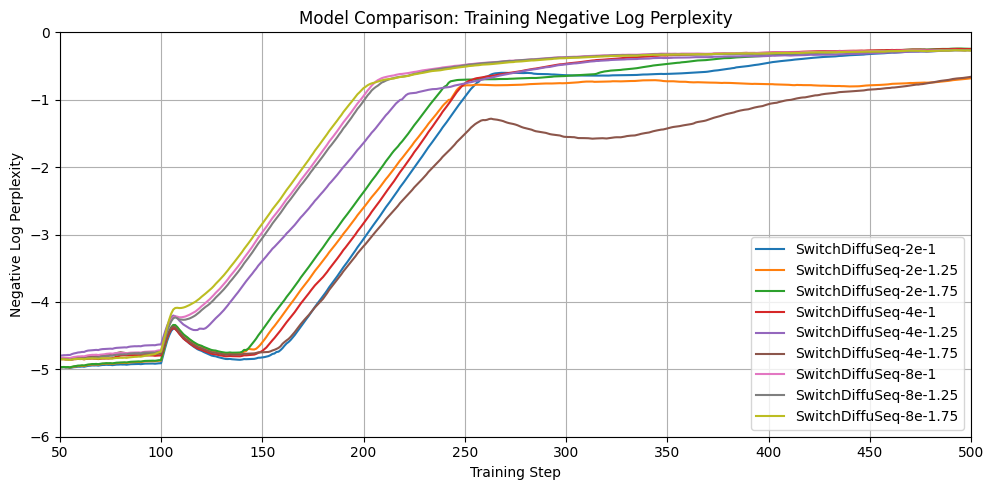

In [47]:
import pandas as pd
import matplotlib.pyplot as plt


model_files = {
    "SwitchDiffuSeq-2e-1": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1/ppl_progress_Switch_2e_greet_2000_noclip_cap=1_0902_1335.csv",
    "SwitchDiffuSeq-2e-1.25": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_2e_greet_2000_noclip_cap=1.25_0902_1143.csv",
    "SwitchDiffuSeq-2e-1.75": "models/final models/greetings/final models no clip/Switch_2e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_2e_greet_2000_noclip_0901_1843.csv",
    "SwitchDiffuSeq-4e-1": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1/ppl_progress_Switch_4e_greet_2000_noclip_cap=1_0902_1423.csv",
    "SwitchDiffuSeq-4e-1.25": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_4e_greet_2000_noclip_cap=1.25_0902_1152.csv",
    "SwitchDiffuSeq-4e-1.75": "models/final models/greetings/final models no clip/Switch_4e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_4e_greet_2000_noclip_0901_1758.csv",
    "SwitchDiffuSeq-8e-1": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1/ppl_progress_Switch_8e_greet_2000_noclip_cap=1_0902_1426.csv",
    "SwitchDiffuSeq-8e-1.25": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.25/ppl_progress_Switch_8e_greet_2000_noclip_cap=1.25_0902_1324.csv",
    "SwitchDiffuSeq-8e-1.75": "models/final models/greetings/final models no clip/Switch_8e_greet_2000_noclip_cap=1.75/ppl_progress_multiple_Switch_8e_greet_2000_noclip_0901_1912.csv",
}
plt.figure(figsize=(10, 5))

def smooth(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean()

for label, filepath in model_files.items():
    df = pd.read_csv(filepath)
    df = df.dropna(subset=["train_neg_log_ppl"])
    smoothed = smooth(df["train_neg_log_ppl"], window=100)
    plt.plot(df["step"], smoothed, label=label)
    plt.xlabel("Training Step")
    
plt.ylabel("Negative Log Perplexity")
plt.title("Model Comparison: Training Negative Log Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(50, 500)
plt.ylim(-6, 0)
plt.show()